In [1]:
#Version Numbers Used to Generate this Pset:
#seaborn=0.11.2
#scipy==1.8.0
#numpy==1.22.2
#matplotlib==3.5.1

import scipy as sp
from pylab import *
import numpy as np
import matplotlib as mpl
from matplotlib import pyplot as plt
from matplotlib.ticker import MultipleLocator,FormatStrFormatter,MaxNLocator
import pandas as pd
import seaborn as sns
import collections
from IPython.display import clear_output
import random
import openpyxl
import os 
sns.set_style("ticks")
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, explained_variance_score, r2_score
from sklearn.preprocessing import PolynomialFeatures
import pickle
from matplotlib.colors import LogNorm  # Import LogNorm for logarithmic color scale

DataTitle="Data_dynamics"

np.random.seed(1)
if not os.path.exists(DataTitle):

   # Create a new directory because it does not exist
   os.makedirs(DataTitle)
   print("The new directory is created!")

mm = 0.1/2.54
os.environ['PATH'] = os.environ['PATH'] + ':/Library/TeX/texbin/latex'
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['font.family'] = 'Arial'
mpl.rcParams['figure.dpi'] = 600
mpl.rcParams['font.size'] = 8
mpl.rcParams['axes.linewidth'] = 0.5
mpl.rcParams['xtick.minor.width'] = 0.4
mpl.rcParams['xtick.major.width'] = 0.5
mpl.rcParams['ytick.minor.width'] = 0.4
mpl.rcParams['ytick.major.width'] = 0.5

plt.rcParams['text.usetex'] = False
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'

sns.color_palette("tab10")

[(0.12156862745098039, 0.4666666666666667, 0.7058823529411765),
 (1.0, 0.4980392156862745, 0.054901960784313725),
 (0.17254901960784313, 0.6274509803921569, 0.17254901960784313),
 (0.8392156862745098, 0.15294117647058825, 0.1568627450980392),
 (0.5803921568627451, 0.403921568627451, 0.7411764705882353),
 (0.5490196078431373, 0.33725490196078434, 0.29411764705882354),
 (0.8901960784313725, 0.4666666666666667, 0.7607843137254902),
 (0.4980392156862745, 0.4980392156862745, 0.4980392156862745),
 (0.7372549019607844, 0.7411764705882353, 0.13333333333333333),
 (0.09019607843137255, 0.7450980392156863, 0.8117647058823529)]

In [2]:
from matplotlib.colors import ListedColormap, LinearSegmentedColormap

my_cmap = ListedColormap(['#00429d', '#4771b2', '#73a2c6', '#a5d5d8', '#ffffe0', '#ffbcaf', '#f4777f', '#cf3759', '#93003a'], name="my_cmap")
my_cmap_r = my_cmap.reversed()
mpl.colormaps.register(cmap=my_cmap)
mpl.colormaps.register(cmap=my_cmap_r)

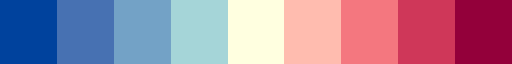

In [3]:
my_cmap

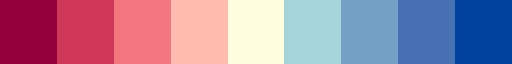

In [4]:
my_cmap_r

In [5]:
def getIDX(data, IDX):
    O = np.flatnonzero([x == IDX for x in data['SampleIDX']])
    return np.array(O)

def getAbundance(Processed_sequences,IDX):
    SampleIdx= np.flatnonzero([x == IDX for x in Processed_sequences['SampleIDX']])
    if not any(SampleIdx):
        return
    else:
        O=Processed_sequences.iloc[SampleIdx].values.tolist()[0][1:]
        return O

def getAbundance_fromList(Processed_sequences,IDX_list):
    IDX_list_=np.squeeze([np.where(Processed_sequences['SampleIDX']==x) for x in IDX_list])
    return (np.array(Processed_sequences.iloc[IDX_list_].values)[:,1:]).astype(float)

def Community_PermutateList_simulation(I,S):
    global Metadata,exception_list
    sample_num=100
    O=(3*(I-1)+(S-1))*100+np.arange(0,100)
    return O

def CommunityPermutate(Timepoint, CommunityOrigin, Medium, CoalescenceType):
    global Metadata
    idx = np.where((Metadata['Timepoint'] == Timepoint) &
                   (Metadata['CommunityOrigin'] == CommunityOrigin) &
                   (Metadata['Medium'] == Medium) &
                   (Metadata['CoalescenceType'] == CoalescenceType))[0]
    O = np.concatenate(Metadata['SampleIDX'][idx])
    return O

def CommunityPermutate_withSpeciesPoolsize(Timepoint, CommunityOrigin, Medium, CoalescenceType, species_pool_num):
    global Metadata,exception_list
    idx = (Metadata['Timepoint'] == Timepoint) & \
          (Metadata['CommunityOrigin'] == CommunityOrigin) & \
          (Metadata['Medium'] == Medium) & \
          (Metadata['CoalescenceType'] == CoalescenceType)

    communityIDX = np.array([int(x) for x in Metadata['CommunityIDX']])
    if CoalescenceType == 'S':
        if species_pool_num == 6:
            idx = idx & (communityIDX <= 9)
        elif species_pool_num == 12:
            idx = idx & ((communityIDX > 9) & (communityIDX <= 18))
        elif species_pool_num == 24:
            idx = idx & ((communityIDX > 18) & (communityIDX <= 30))
    elif CoalescenceType == 'C':
        if species_pool_num == 6:
            idx = idx & (communityIDX <= 14)
        elif species_pool_num == 12:
            idx = idx & ((communityIDX > 14) & (communityIDX <= 41))
        elif species_pool_num == 24:
            idx = idx & ((communityIDX > 41) & (communityIDX <= 47))

    O = Metadata['SampleIDX'][idx]
    O = list(set(O) - set(exception_list))
    return O

def Community_PermutateList(Timepoint, CommunityOrigin, Medium, CoalescenceType, species_pool_num=0, Replicate=-1):
    global Metadata,exception_list
    
    if Replicate==-1:
        idx = (Metadata['Timepoint'] == Timepoint) & \
              (Metadata['CommunityOrigin'] == CommunityOrigin) & \
              (Metadata['Medium'] == Medium) & \
              (Metadata['CoalescenceType'] == CoalescenceType)
    elif Replicate == 1 or Replicate == 2 : 
        idx = (Metadata['Timepoint'] == Timepoint) & \
              (Metadata['CommunityOrigin'] == CommunityOrigin) & \
              (Metadata['Medium'] == Medium) & \
              (Metadata['CoalescenceType'] == CoalescenceType) & \
              (Metadata['Replicate'] == Replicate)
    else : 
        raise ValueError("Invalid input")

    
    if CommunityOrigin=='S':
        communityIDX = np.array([int(x) for x in Metadata['CommunityIDX']])
        if CoalescenceType == 'S':
            if species_pool_num == 6:
                idx = idx & (communityIDX <= 9)
            elif species_pool_num == 12:
                idx = idx & ((communityIDX > 9) & (communityIDX <= 18))
            elif species_pool_num == 24:
                idx = idx & ((communityIDX > 18) & (communityIDX <= 30))
            elif species_pool_num ==0:
                idx = idx
        elif CoalescenceType == 'C':
            if species_pool_num == 6:
                idx = idx & (communityIDX <= 14)
            elif species_pool_num == 12:
                idx = idx & ((communityIDX > 14) & (communityIDX <= 41))
            elif species_pool_num == 24:
                idx = idx & ((communityIDX > 41) & (communityIDX <= 47))
            elif species_pool_num ==0:
                idx = idx
    elif CommunityOrigin=='N':
        communityIDX = np.array([int(x) for x in Metadata['CommunityIDX']])
        
    O = Metadata['SampleIDX'][idx]
    O = list(set(O) - set(exception_list))
    return O

def getCommunities(Communities_data,IDX_list):
    IDX_list_=np.squeeze([np.where(Communities_data['SampleIDX']==x) for x in IDX_list])
    return (Communities_data.iloc[IDX_list_])

def getCoalescence(Coalescence_data,IDX_list):
    IDX_list_=np.squeeze([np.where(Coalescence_data['SampleIDX']==x) for x in IDX_list])#IDX_list_
    return (Coalescence_data.iloc[IDX_list_])

Coalescence_data_synthetic_path ="../../Analyzed/processed_CoalescenceEvent_synthetic.xlsx"
Communities_data_synthetic_path ="../../Analyzed/processed_Communities_synthetic.xlsx"
Coalescence_data_natural_path ="../../Analyzed/processed_CoalescenceEvent_natural.xlsx"
Communities_data_natural_path ="../../Analyzed/processed_Communities_natural.xlsx"
Coalescence_recipe_path="../../Postprocessed/CoalescenceRecipe.xlsx"
Meta_data_path="../../Postprocessed/Metadata.xlsx"
Processed_sequences_synthetic_path="../../Postprocessed/processed_Sequences_synthetic.xlsx"
Processed_sequences_natural_path="../../Postprocessed/processed_Sequences_natural.xlsx"
Coalescence_data_sim_path="../../Analyzed/processed_CoalescenceEvent_simulation_uniform.xlsx"
#Communities_data_sim_path="Analyzed/processed_Communities_simulation_uniform.xlsx"

Coalescence_data=pd.concat([pd.read_excel(Coalescence_data_synthetic_path),pd.read_excel(Coalescence_data_natural_path)])
Communities_data=pd.concat([pd.read_excel(Communities_data_synthetic_path),pd.read_excel(Communities_data_natural_path)])
Coalescence_data_sim=pd.read_excel(Coalescence_data_sim_path)
#Communities_data_sim=pd.read_excel(Communities_data_sim_path)

Coalescence_recipe=pd.read_excel(Coalescence_recipe_path,sheet_name=0)
Coalescence_natural_recipe=pd.read_excel(Coalescence_recipe_path,sheet_name=1)
Metadata=pd.read_excel(Meta_data_path)
Processed_sequences_synthetic=pd.read_excel(Processed_sequences_synthetic_path)
Processed_sequences_natural=pd.read_excel(Processed_sequences_natural_path)

exception_list=['P4-02','P4-03','P4-23','P4-24','P7-97', 'P8-12']+['P8-91'] + ['P5-73', 'P5-69','P5-64','P5-61','P5-59', 'P5-56'] + ['P5-47', 'P5-50'] + ['P5-39', 'P5-87', 'P5-54', 'P6-02', 'P6-47', 'P6-74', 'P6-57']
#'P4-02','P4-03','P4-23','P4-24','P7-97', 'P8-12' : These cases are for no reads in coalescence result
# 'P8-91' : no file
#['P5-73', 'P5-69','P5-64','P5-61','P5-59', 'P5-56'] : MN E7 is missing
# 'P6-67' : is too low reads( 500)
# 'P5-47', 'P5-50' : MN24 CC, too much unwanted ASVs(maybe due to wrong labeling)
# ['P5-39', 'P5-87', 'P5-54', 'P6-02', 'P6-47', 'P6-74', 'P6-57'] : ASV not in sub 2> 0.3

I = [0.33, 0.66, 0.99]
species_pools = [6, 12, 24]
sample_num=100
Syn_Simulation_IDX = {
    "I1_S1": Community_PermutateList_simulation(1,1),
    "I1_S2": Community_PermutateList_simulation(1,2),
    "I1_S3": Community_PermutateList_simulation(1,3),
    "I2_S1": Community_PermutateList_simulation(2,1),
    "I2_S2": Community_PermutateList_simulation(2,2),
    "I2_S3": Community_PermutateList_simulation(2,3),
    "I3_S1": Community_PermutateList_simulation(3,1),
    "I3_S2": Community_PermutateList_simulation(3,2),
    "I3_S3": Community_PermutateList_simulation(3,3),
}
mediums_pools = ["LN", "MN", "HN"]
species_pools = [6, 12, 24]
Syn_Coal_IDX = {
    "LN_6": Community_PermutateList("F", "S", "L", "C", 6),
    "LN_12": Community_PermutateList("F", "S", "L", "C", 12),
    "LN_24": Community_PermutateList("F", "S", "L", "C", 24),
    "MN_6": Community_PermutateList("F", "S", "M", "C", 6),
    "MN_12": Community_PermutateList("F", "S", "M", "C", 12),
    "MN_24": Community_PermutateList("F", "S", "M", "C", 24),
    "HN_6": Community_PermutateList("F", "S", "H", "C", 6),
    "HN_12": Community_PermutateList("F", "S", "H", "C", 12),
    "HN_24": Community_PermutateList("F", "S", "H", "C", 24)
}
Syn_Sub_IDX = {
    "LN_6": Community_PermutateList("F", "S", "L", "S", 6),
    "LN_12": Community_PermutateList("F", "S", "L", "S", 12),
    "LN_24": Community_PermutateList("F", "S", "L", "S", 24),
    "MN_6": Community_PermutateList("F", "S", "M", "S", 6),
    "MN_12": Community_PermutateList("F", "S", "M", "S", 12),
    "MN_24": Community_PermutateList("F", "S", "M", "S", 24),
    "HN_6": Community_PermutateList("F", "S", "H", "S", 6),
    "HN_12": Community_PermutateList("F", "S", "H", "S", 12),
    "HN_24": Community_PermutateList("F", "S", "H", "S", 24)
}
Nat_Coal_IDX = {
    "LN": Community_PermutateList("F", "N", "L", "C"),
    "MN": Community_PermutateList("F", "N", "M", "C"),
    "HN": Community_PermutateList("F", "N", "H", "C")
}
Nat_Sub_IDX = {
    "LN": Community_PermutateList("F", "N", "L", "S"),
    "MN": Community_PermutateList("F", "N", "M", "S"),
    "HN": Community_PermutateList("F", "N", "H", "S")
}




########################################################
########################################################
# Fig 4-1
########################################################
########################################################

##~~~~~~~~~~~~~~ This figure is cartoon ~~~~~~~~~~~~~~##

In [6]:
def pHcriteria(pH_list,return_type="Num"):
    pH_list=np.array(pH_list)
    O=1*(pH_list>6)+1*(pH_list>8)
    if return_type=="Num":
        return O
    if return_type=="Word":
        word_list=['acidic','neutral','alkalic']
        return [word_list[x] for x in O]
    if return_type=="Color":
        word_list=['r','g','b']
        return [word_list[x] for x in O]

def getDominanceMatrix(Variable2plot, Coalescence_data, Coal_IDX_list, Sub_IDX_list):
    N=len(Sub_IDX_list)
    matrix={Sub_IDX : {} for Sub_IDX in Sub_IDX_list }
    for SampleIDX in Coal_IDX_list:
        idx=np.where(Coalescence_data['SampleIDX']==SampleIDX)
        dominance1=Coalescence_data.iloc[idx][Variable2plot].tolist()[0]
        dominance2=1-dominance1
        subSampleIDX1=Coalescence_data.iloc[idx]["SampleIDX_Sub1"].tolist()[0]
        #subidx1=np.where(Sub_IDX_list==subSmapleIDX1)
        subSampleIDX2=Coalescence_data.iloc[idx]["SampleIDX_Sub2"].tolist()[0]


        #subidx2=np.where(Sub_IDX_list==subSmapleIDX2)
        matrix[subSampleIDX1].update({subSampleIDX2:dominance1})
        matrix[subSampleIDX2].update({subSampleIDX1:dominance2})
    for SampleIDX in Sub_IDX_list:
        matrix[SampleIDX].update({SampleIDX:0.5})
    
    return matrix   

def EstimateErrorLassoRegression(IDX_list, x, y, order, alpha, beta, preprocess='Basic', verbose=False):
    communityIDX_list=np.unique(getCommunities(Communities_data,IDX_list)['CommunityIDX'])
    train_mse_list=[]
    test_mse_list=[]
    
    if preprocess=='Basic':
        y_tofit=y.copy()
    elif preprocess=='Normalize':
        y_tofit=(y.copy()-0.5)*2
    elif preprocess=='Tan':
        y_tofit=np.tan((y.copy()-0.5)*np.pi/2)
    
    fig=plt.figure(figsize=(70*mm,60*mm))

    for communityID_toTest in communityIDX_list:  
        getCommunities(Communities_data,Community_PermutateList("F", com_type, medium, "S", species_num, rep))
        train_idx_list=np.where(getCommunities(Communities_data,IDX_list)['CommunityIDX']!=communityID_toTest)[0]
        test_idx_list=np.where(getCommunities(Communities_data,IDX_list)['CommunityIDX']==communityID_toTest)[0]

        # Generate synthetic data
        X_train = beta*x[train_idx_list,:]
        y_train = y_tofit[train_idx_list]#y[:]
        X_test = beta*x[test_idx_list,:]
        y_test = y_tofit[test_idx_list]
        # Split data into training and testing sets
        
        # Transform features to include up to second-order terms
        polynomial_features = PolynomialFeatures(degree=order, include_bias=True)
        X_train_poly = polynomial_features.fit_transform(X_train)
        X_test_poly = polynomial_features.transform(X_test)

        # Create the model
        model = Lasso(alpha=alpha, max_iter = 1000)

        # Fit the model to the training data
        model.fit(X_train_poly, y_train)

        # Predict the target values for the test set
        y_pred_train = model.predict(X_train_poly)
        y_pred_test = model.predict(X_test_poly)

        # Evaluate the model
        train_mse = np.mean((y_train-y_pred_train)**2)
        test_mse = np.mean((y_test-y_pred_test)**2)
        ref_mse= np.var(y_tofit)
        if verbose:
            print(f'Mean Train Squared Error: {train_mse}')
            print(f'Mean Test Squared Error: {test_mse, y_test, y_pred_test}')
        plt.scatter(y_test,y_pred_test)
        train_mse_list.append(train_mse/ref_mse)
        test_mse_list.append(test_mse/ref_mse)
    
    range_min=min(plt.xlim()[0],plt.ylim()[0])
    range_max=max(plt.xlim()[1],plt.ylim()[1])
    plt.plot([range_min, range_max],  [range_min,range_max], color='r')
    print([range_min, range_max],  [range_min,range_max])
    plt.text(range_max, range_max, f'Error={mean(test_mse_list)}',color='r', fontsize=6)
    if True:
        getCommunities(Communities_data,Community_PermutateList("F", com_type, medium, "S", species_num, rep))
        train_idx_list=np.where(getCommunities(Communities_data,IDX_list)['CommunityIDX'])[0]
        test_idx_list=[]

        # Generate synthetic data
        X_train = beta*x[train_idx_list,:]
        y_train = y_tofit[train_idx_list]#y[:]
        X_test = beta*x[test_idx_list,:]
        y_test = y_tofit[test_idx_list]
        # Split data into training and testing sets
        
        # Transform features to include up to second-order terms
        polynomial_features = PolynomialFeatures(degree=order, include_bias=True)
        X_train_poly = polynomial_features.fit_transform(X_train)
        #X_test_poly = polynomial_features.transform(X_test)

        # Create the model
        model = Lasso(alpha=alpha, max_iter = 1000)

        # Fit the model to the training data
        model.fit(X_train_poly, y_train)

        
    return communityIDX_list, train_mse_list, test_mse_list ,model, polynomial_features
    

In [7]:
def getDominanceMatrix(Variable2plot, Coalescence_data, Coal_IDX_list, Sub_IDX_list):
    N=len(Sub_IDX_list)
    matrix={convert_ID_to_communityIDX(Sub_IDX) : {} for Sub_IDX in Sub_IDX_list }
    for SampleIDX in Coal_IDX_list:
        idx=np.where(Coalescence_data['SampleIDX']==SampleIDX)
        dominance1=Coalescence_data.iloc[idx][Variable2plot].tolist()[0]
        dominance2=1-dominance1
        subSampleIDX1=convert_ID_to_communityIDX(Coalescence_data.iloc[idx]["SampleIDX_Sub1"].tolist()[0])
        #subidx1=np.where(Sub_IDX_list==subSmapleIDX1)
        subSampleIDX2=convert_ID_to_communityIDX(Coalescence_data.iloc[idx]["SampleIDX_Sub2"].tolist()[0])


        #subidx2=np.where(Sub_IDX_list==subSmapleIDX2)
        matrix[subSampleIDX1].update({subSampleIDX2:dominance1})
        matrix[subSampleIDX2].update({subSampleIDX1:dominance2})
    for SampleIDX in Sub_IDX_list:
        matrix[convert_ID_to_communityIDX(SampleIDX)].update({convert_ID_to_communityIDX(SampleIDX):0.5})
    
    return matrix

In [8]:
def convert_ID_to_communityIDX(SampleIDX):
    idx=np.where(Communities_data['SampleIDX']==SampleIDX)
    if Communities_data.iloc[idx]['CommunityOrigin'].tolist()[0]=='S' and Communities_data.iloc[idx]['CommunityOrigin'].tolist()[0]=='S':
        val=Communities_data.iloc[idx]['CommunityIDX'].tolist()[0]
        if val<9:
            return f'C{val+1}'
        elif val<18:
            return f'C{val-8}'
        else :
            return f'C{val-17}'

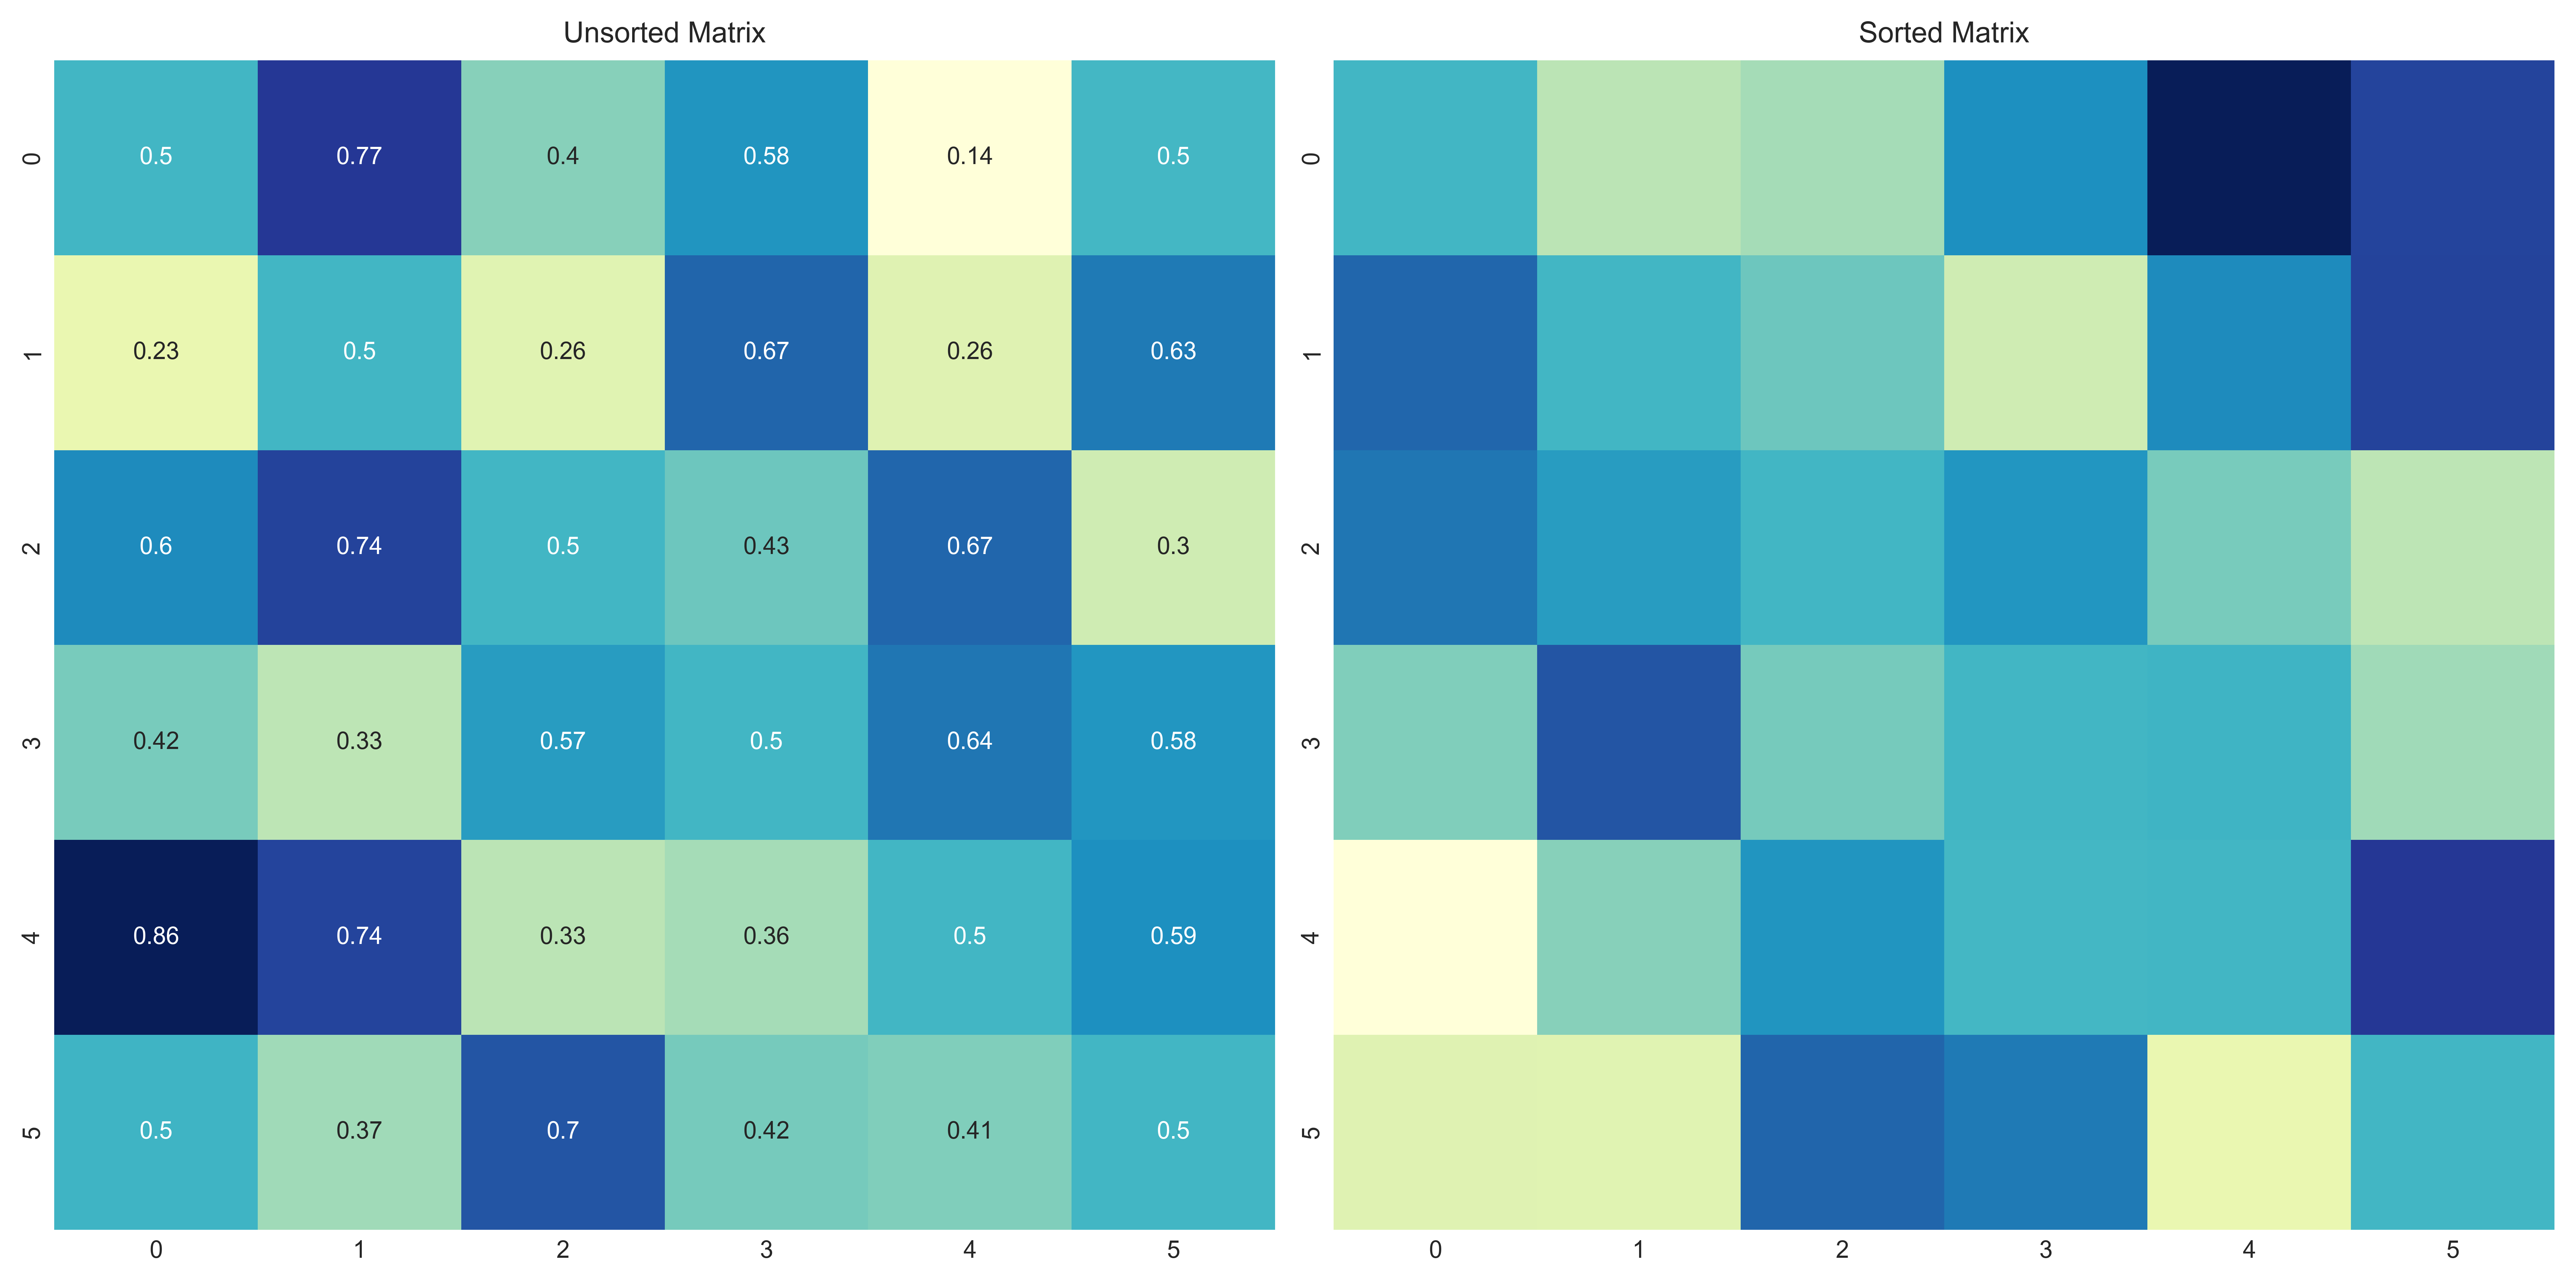

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

N = 6

# Create a random N by N matrix
matrix = np.random.rand(N, N)*0.5
matrix = matrix-matrix.T+0.5

# Calculate row averages
row_averages = np.mean(matrix, axis=1)

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Unsorted Matrix Heatmap
sns.heatmap(matrix, annot=True, cmap="YlGnBu", ax=axes[0], cbar=False)
axes[0].set_title("Unsorted Matrix")

# Sort the matrix by row averages
sorted_indices = np.argsort(row_averages)[::-1]
sorted_matrix = matrix[:,sorted_indices]
sorted_matrix=sorted_matrix[sorted_indices,:]

# Sorted Matrix Heatmap
sns.heatmap(sorted_matrix, annot=False, cmap="YlGnBu", ax=axes[1], cbar=False)
axes[1].set_title("Sorted Matrix")

# Display the heatmaps
plt.tight_layout()
plt.show()

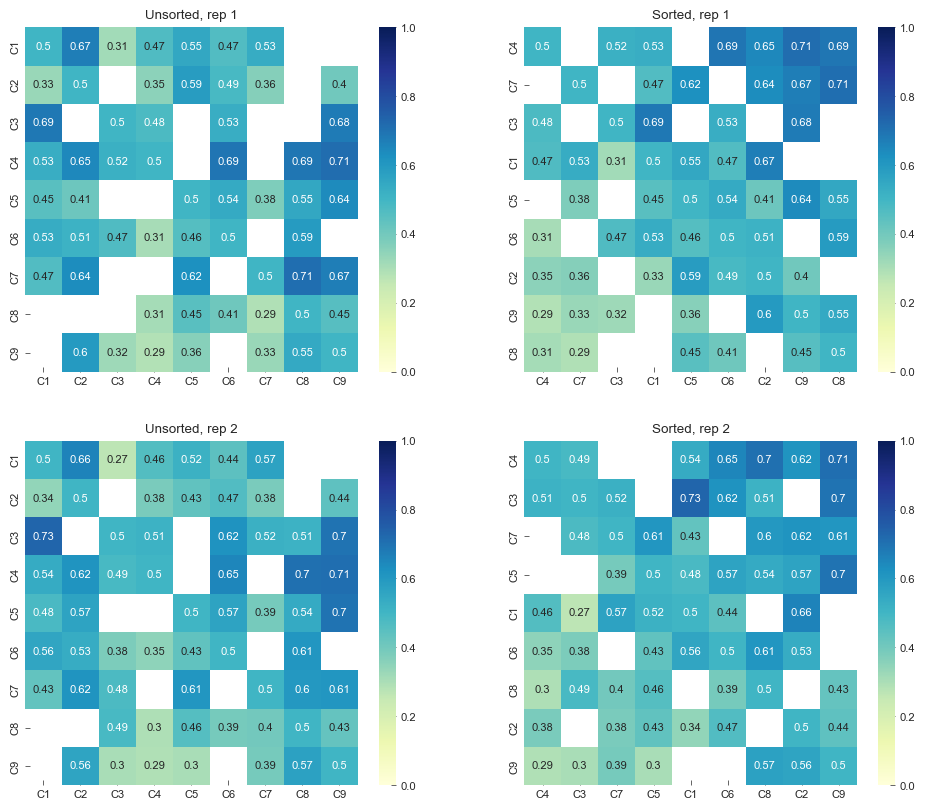

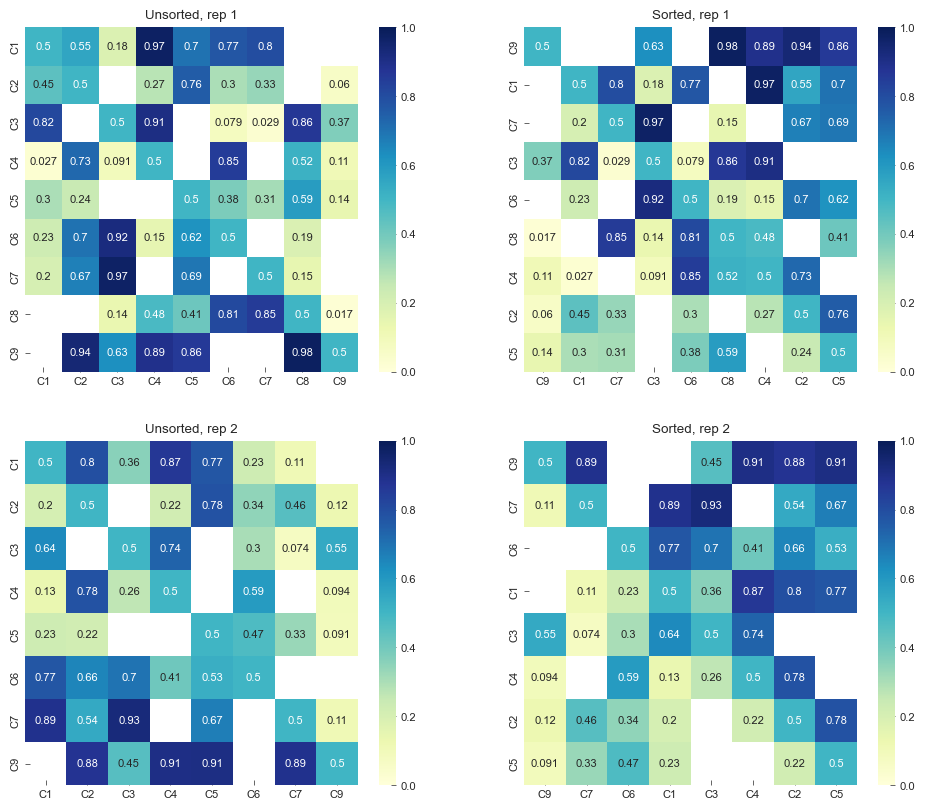

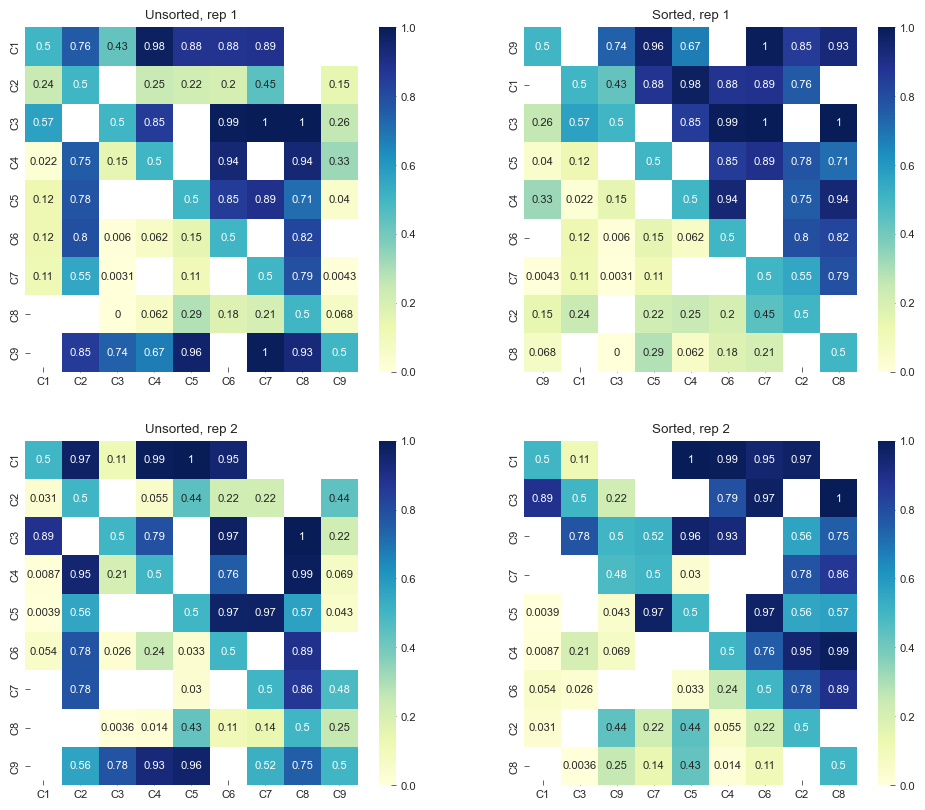

In [10]:
Variable2plot='SimilarityTo1_BC_5'
medium="M"
species_num=12
com_type="S"

for medium in ["L","M","H"]:

    ###
    ###

    #fig=figure(num=None, figsize=(40, 8), dpi=100, facecolor='w', edgecolor='k')
    fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(300*mm, 250*mm), dpi=100, facecolor='w', edgecolor='k')

    rep=1

    Sub_IDX_list=Community_PermutateList("F", com_type, medium, "S", species_num, rep)
    Coal_IDX_list=Community_PermutateList("F", com_type, medium, "C", species_num, rep)

    #Sub_IDX_list=Nat_Sub_IDX['LN']
    #Coal_IDX_list=Nat_Coal_IDX['LN']


    matrix=getDominanceMatrix(Variable2plot, Coalescence_data, Coal_IDX_list, Sub_IDX_list)


    df = pd.DataFrame(matrix)
    df_sorted=df.sort_index(axis=1)
    df_sorted=df_sorted.sort_index(axis=0)
    sns.heatmap(df_sorted, annot=True, cmap='YlGnBu', vmin=0, vmax=1,ax=axs[0,0])
    axs[0,0].set_title("Unsorted, rep 1")
    # Create list of competitive scores

    competitive_scores = [np.mean(df.loc[row_col,:]) for row_col in df_sorted.index]

    # Sort rows and columns by competitive score
    sorted_idx = np.argsort(competitive_scores)[::-1]
    df_sorted = df_sorted.iloc[sorted_idx, sorted_idx]
    df1=df_sorted

    # Create heatmap with clustered rows and columns
    sns.heatmap(df1, annot=True, cmap='YlGnBu', vmin=0, vmax=1,ax=axs[0,1])
    axs[0,1].set_title("Sorted, rep 1")



    rep=2

    Sub_IDX_list=Community_PermutateList("F", com_type, medium, "S", species_num, rep)
    Coal_IDX_list=Community_PermutateList("F", com_type, medium, "C", species_num, rep)

    #Sub_IDX_list=Nat_Sub_IDX['LN']
    #Coal_IDX_list=Nat_Coal_IDX['LN']


    matrix=getDominanceMatrix(Variable2plot, Coalescence_data, Coal_IDX_list, Sub_IDX_list)
    df = pd.DataFrame(matrix)
    df_sorted=df.sort_index(axis=1)
    df_sorted=df_sorted.sort_index(axis=0)
    sns.heatmap(df_sorted, annot=True, cmap='YlGnBu', vmin=0, vmax=1,ax=axs[1,0])
    axs[1,0].set_title("Unsorted, rep 2")
    # Create list of competitive scores

    # Create list of competitive scores

    competitive_scores = [np.mean(df.loc[row_col,:]) for row_col in df_sorted.index]

    # Sort rows and columns by competitive score
    sorted_idx = np.argsort(competitive_scores)[::-1]
    df_sorted = df_sorted.iloc[sorted_idx, sorted_idx]
    df2=df_sorted

    # Create heatmap with clustered rows and columns
    sns.heatmap(df2, annot=True, cmap='YlGnBu', vmin=0, vmax=1,ax=axs[1,1])
    axs[1,1].set_title("Sorted, rep 2")



    plt.savefig(f'Figure/Fig_4-1_MatrixPlot_medium_{medium}_S12.svg', bbox_inches='tight')
    plt.show()





In [11]:
def calculate_hierarchy_score(matrix):
    # get lower triangle of sorted matrix
    
    mean_indices = np.argsort(-np.nanmean(matrix, axis=1))
    # get mean of each column and sort indices
    col_mean_indices = np.argsort(np.nanmean(matrix, axis=0))
    
    # create sorted matrix based on sorted row and column indices
    sorted_matrix = matrix[mean_indices][:, col_mean_indices]
                                         
    lower_triangle = np.tril(sorted_matrix, k=-1)
    # get non-NaN values in lower triangle
    mask = np.tril(np.ones_like(sorted_matrix), k=-1).astype(np.bool)
    non_nan_values = sorted_matrix[mask][~np.isnan(sorted_matrix[mask])]
    
    # calculate sum and count of non-NaN values
    sum_non_nan = np.sum(non_nan_values)
    num_non_nan = len(non_nan_values)
    
    # calculate hierarchy score
    hierarchy_score = 1 - sum_non_nan / num_non_nan
    
    return hierarchy_score

def generate_random_matrix(matrix):
    random_fractions = np.random.choice(matrix.flatten(), size=matrix.size, replace=True)
    random_matrix = np.zeros(matrix.shape)
    idx=np.tril_indices(matrix.shape[0],k=-1)
    flip_index=2*(np.random.rand(len(idx[0]))>0.5)-1

    random_matrix[np.tril_indices(matrix.shape[0],k=-1)] = 0.5+(random_fractions[0:len(idx[0])]-0.5)*flip_index
    random_matrix[np.triu_indices(matrix.shape[0],k=1)] = 0.5-(random_fractions[0:len(idx[0])]-0.5)*flip_index
    np.fill_diagonal(random_matrix, 0.5)
    
    return random_matrix

def calculate_significance(matrix, n_samples=1000):
    # Calculate hierarchy score for original matrix
    hierarchy_score = calculate_hierarchy_score(matrix)
    
    # Generate random matrices and calculate hierarchy scores
    random_scores = []
    for i in range(n_samples):
        random_matrix = generate_random_matrix(matrix)
        random_scores.append(calculate_hierarchy_score(random_matrix))
    
    # Calculate p-value
    random_scores = np.array(random_scores)
    p_value = (random_scores >= hierarchy_score).sum() / n_samples
    
    return random_scores, p_value



/var/folders/ml/8vkvr85554d3lhwlyxkmt_240000gn/T/ipykernel_29249/2288912246.py:13: FutureWarning: In the future `np.bool` will be defined as the corresponding NumPy scalar.
  mask = np.tril(np.ones_like(sorted_matrix), k=-1).astype(np.bool)


AttributeError: module 'numpy' has no attribute 'bool'.
`np.bool` was a deprecated alias for the builtin `bool`. To avoid this error in existing code, use `bool` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.bool_` here.
The aliases was originally deprecated in NumPy 1.20; for more details and guidance see the original release note at:
    https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations

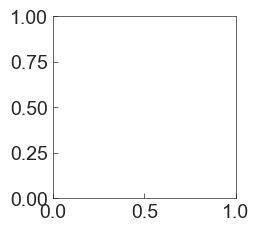

In [12]:
typeofplot="heatmap"
mpl.rcParams['font.size'] = 14

#'swarmpoint' #'swarmbox' # choose among 'swarmbox', 'swarmpoint', violin

Variable2plot_list=['SimilarityTo1_BC_5']
    #['Additivity3_3', 'Assymetricity_BC_3', 'Assymetricity_J_3', 'Assymetricity_JS_3',
       #'Assymetricity1_3', 'Assymetricity2_3', 'Assymetricity3_3']
        
M = [0.33, 0.66, 0.99]
species_pools = [12]
HueVariable='label'
hue_order = [0,1,2]
rep=1
Variable2plot='SimilarityTo1_BC_5'
medium="M"
species_num=12
com_type="S"

for medium in ['L', 'M', 'H']:
    rep=1
    Sub_IDX_list=Community_PermutateList("F", com_type, medium, "S", species_num, -1)
    Coal_IDX_list=Community_PermutateList("F", com_type, medium, "C", species_num, -1)

    matrix=getDominanceMatrix(Variable2plot, Coalescence_data, Coal_IDX_list, Sub_IDX_list)
    df = pd.DataFrame(matrix)
    df_sorted=df.sort_index(axis=1)
    df_sorted=df_sorted.sort_index(axis=0)

    fig, axs = plt.subplots(nrows=1, ncols=1, figsize=(60*mm, 60*mm), dpi=100, facecolor='w', edgecolor='k')
                
    hs1=calculate_hierarchy_score(df.values)
    permutated_scores1, p_value1=calculate_significance(df.values,20000)
    
    rep=2
    Sub_IDX_list=Community_PermutateList("F", com_type, medium, "S", species_num, rep)
    Coal_IDX_list=Community_PermutateList("F", com_type, medium, "C", species_num, rep)

    matrix=getDominanceMatrix(Variable2plot, Coalescence_data, Coal_IDX_list, Sub_IDX_list)
    df = pd.DataFrame(matrix)
    df_sorted=df.sort_index(axis=1)
    df_sorted=df_sorted.sort_index(axis=0)

                
    hs2=calculate_hierarchy_score(df.values)
    permutated_scores2, p_value2=calculate_significance(df.values,10000)
    
    plt.hist(permutated_scores1, bins=50, alpha=0.5, range=(0.5,0.9), label='Shuffled', linewidth=0, density=True)
    print(hs1,hs2)
    print(p_value1,p_value2,1-(1-p_value1)*(1-p_value2))
    # plot dotted line for actual score
    plt.axvline(x=hs1, linestyle='--', color='red', label='Rep 1')
    plt.axvline(x=hs2, linestyle='--', color='orange', label='Rep 2')
    
    #plt.text(0.1, 0.9, f'p = {p_value:.4f}', ha='center', va='center', transform=plt.gca().transAxes)

    plt.xlabel('Hierarchy Scores')
    plt.ylabel('Frequency')
    
    # show plot
    plt.savefig(f'Figure/Fig_4-2_HS_medium_{medium}_S12.svg', bbox_inches='tight')
    plt.show()

    #fig.savefig("Figures/0320_analysis/Hiearchy_Analysis_axisLabeledBypH_"+'_'+Variable2plot+'_'+com_type+'_'+medium+'_'+str(species_num)+"_rep_"+str(rep)+".png", bbox_inches='tight')


#AllAbudnaces=getAbundance(Metadata['SampleIDX'])

In [ ]:
actual_scores = [0.65, 0.667]
null_means = [0.425, 0.400]
null_stds = [0.084, 0.082]

array([[0.5       , 0.96924003, 0.11235663, 0.99125415, 0.99612538,
        0.94554236,        nan,        nan,        nan],
       [0.03075997, 0.5       ,        nan, 0.05464768, 0.44406539,
        0.22259291, 0.22251166,        nan, 0.44051409],
       [0.88764337,        nan, 0.5       , 0.78975069,        nan,
        0.97357031,        nan, 0.99640522, 0.22158698],
       [0.00874585, 0.94535232, 0.21024931, 0.5       ,        nan,
        0.75633031,        nan, 0.98552633, 0.06902566],
       [0.00387462, 0.55593461,        nan,        nan, 0.5       ,
        0.9674801 , 0.97014054, 0.57349592, 0.04284837],
       [0.05445764, 0.77740709, 0.02642969, 0.24366969, 0.0325199 ,
        0.5       ,        nan, 0.89328989,        nan],
       [       nan, 0.77748834,        nan,        nan, 0.02985946,
               nan, 0.5       , 0.86491672, 0.47810031],
       [       nan,        nan, 0.00359478, 0.01447367, 0.42650408,
        0.10671011, 0.13508328, 0.5       , 0.25321047],


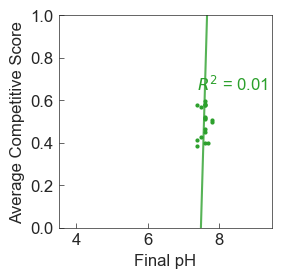

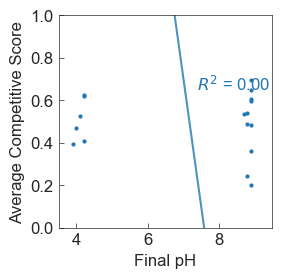

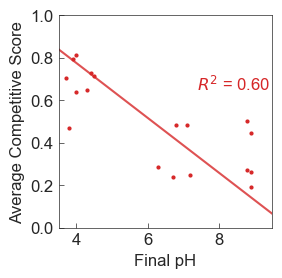

In [14]:
## Hiearchy Plot with PH
mpl.rcParams['font.size'] = 12


def getDominanceMatrix(Variable2plot, Coalescence_data, Coal_IDX_list, Sub_IDX_list):
    N=len(Sub_IDX_list)
    matrix={Sub_IDX : {} for Sub_IDX in Sub_IDX_list }
    for SampleIDX in Coal_IDX_list:
        idx=np.where(Coalescence_data['SampleIDX']==SampleIDX)
        dominance1=Coalescence_data.iloc[idx][Variable2plot].tolist()[0]
        dominance2=1-dominance1
        subSampleIDX1=Coalescence_data.iloc[idx]["SampleIDX_Sub1"].tolist()[0]
        #subidx1=np.where(Sub_IDX_list==subSmapleIDX1)
        subSampleIDX2=Coalescence_data.iloc[idx]["SampleIDX_Sub2"].tolist()[0]


        #subidx2=np.where(Sub_IDX_list==subSmapleIDX2)
        matrix[subSampleIDX1].update({subSampleIDX2:dominance1})
        matrix[subSampleIDX2].update({subSampleIDX1:dominance2})
    for SampleIDX in Sub_IDX_list:
        matrix[SampleIDX].update({SampleIDX:0.5})
    
    return matrix



typeofplot="heatmap"
#'swarmpoint' #'swarmbox' # choose among 'swarmbox', 'swarmpoint', violin

Variable2plot_list=['SimilarityTo1_BC_3']
    #['Additivity3_3', 'Assymetricity_BC_3', 'Assymetricity_J_3', 'Assymetricity_JS_3',
       #'Assymetricity1_3', 'Assymetricity2_3', 'Assymetricity3_3']
        
M = [0.33, 0.66, 0.99]
species_pools = [12]
HueVariable='label'
hue_order = [0,1,2]
rep=1


colors=[sns.color_palette("tab10")[2], sns.color_palette("tab10")[0], sns.color_palette("tab10")[3]]
for i, medium in enumerate(['L','M','H']):
    fig, axs = plt.subplots(nrows=1, ncols=1, figsize=(70*mm, 70*mm), dpi=100, facecolor='w', edgecolor='k')

    Sub_IDX_list=Community_PermutateList("F", com_type, medium, "S", species_num, -1)
    Coal_IDX_list=Community_PermutateList("F", com_type, medium, "C", species_num, -1)

                #Sub_IDX_list=Nat_Sub_IDX['LN']
                #Coal_IDX_list=Nat_Coal_IDX['LN']


    matrix=getDominanceMatrix(Variable2plot, Coalescence_data, Coal_IDX_list, Sub_IDX_list)
    df = pd.DataFrame(matrix)
    df_sorted=df.sort_index(axis=1)
    df_sorted=df_sorted.sort_index(axis=0)
    competitive_scores = [1-np.mean(df.loc[row_col,:]) for row_col in df_sorted.index]

                # Sort rows and columns by competitive score
    sorted_idx = np.argsort(competitive_scores)
    df_sorted = df_sorted.iloc[sorted_idx, sorted_idx]
    df1=df_sorted

    com_columns=getCommunities(Communities_data,df_sorted.columns.tolist())
                
    competitive_scores = [1-np.mean(df.loc[row_col,:]) for row_col in df_sorted.index]
       
    x=np.array(competitive_scores)
    x_var='fieldPH7'
    #y=getCommunities(Communities_data,Sub_IDX_list).iloc[:][x_var]
    y=getCommunities(Communities_data,df_sorted.columns.tolist())[x_var].tolist()
    slope, intercept = np.polyfit(x, y, 1)
    y_pred = slope * x + intercept
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r_squared = 1 - (ss_res / ss_tot)
    '''
    # Create a scatter plot of the data
    plt.scatter(x, y, color=colors[i], s=4)
    # Add the linear regression line to the plot
    plt.plot([0,1], slope * np.array([0,1]) + intercept, color=colors[i], alpha=0.8)
                # Add the R-squared value to the plot
    plt.annotate('$R^2$ = {:.2f}'.format(r_squared), xy=(0.05+0.6, 0.65), xycoords='axes fraction', fontsize=12, color=colors[i])

    plt.xlabel('Average Competitive Score')
    plt.ylabel('Final pH')
    plt.xlim(0,1)
    plt.ylim(3.5,9.5)

    
    plt.savefig(f'Figure/Fig_4-2_with_PH_medium_{medium}_S12.svg', bbox_inches='tight')
    '''
        # Create a scatter plot of the data
    plt.scatter(y, x, color=colors[i], s=4)
    # Add the linear regression line to the plot
    plt.plot(slope * np.array([0,1]) + intercept, [0,1], color=colors[i], alpha=0.8)
                # Add the R-squared value to the plot
    plt.annotate('$R^2$ = {:.2f}'.format(r_squared), xy=(0.05+0.6, 0.65), xycoords='axes fraction', fontsize=12, color=colors[i])

    plt.ylabel('Average Competitive Score')
    plt.xlabel('Final pH')
    plt.ylim(0,1)
    plt.xlim(3.5,9.5)
    plt.savefig(f'Figure/Fig_4-2_with_PH_medium_{medium}_S12_reverted.svg', bbox_inches='tight')
    

In [15]:
slope * np.array([0,1]) + intercept

array([10.00657893,  2.2602683 ])

84 20
74 20
96 8


/var/folders/ml/8vkvr85554d3lhwlyxkmt_240000gn/T/ipykernel_34419/2651017529.py:86: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  if int(np.sign(competitive_scores[jj]-competitive_scores[ii]))*np.int(np.sign(df_sorted.values[ii,jj]-0.5))==1:


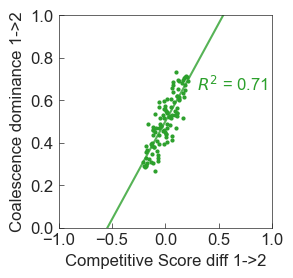

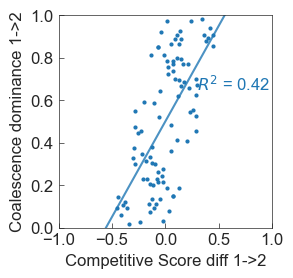

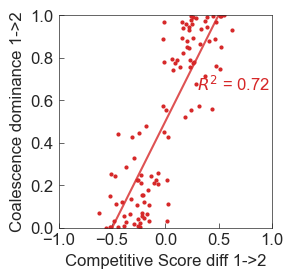

In [16]:
from scipy.stats import rankdata

## Hiearchy Plot with PH
mpl.rcParams['font.size'] = 12


def getDominanceMatrix(Variable2plot, Coalescence_data, Coal_IDX_list, Sub_IDX_list):
    N=len(Sub_IDX_list)
    matrix={Sub_IDX : {} for Sub_IDX in Sub_IDX_list }
    for SampleIDX in Coal_IDX_list:
        idx=np.where(Coalescence_data['SampleIDX']==SampleIDX)
        dominance1=Coalescence_data.iloc[idx][Variable2plot].tolist()[0]
        dominance2=1-dominance1
        subSampleIDX1=Coalescence_data.iloc[idx]["SampleIDX_Sub1"].tolist()[0]
        #subidx1=np.where(Sub_IDX_list==subSmapleIDX1)
        subSampleIDX2=Coalescence_data.iloc[idx]["SampleIDX_Sub2"].tolist()[0]


        #subidx2=np.where(Sub_IDX_list==subSmapleIDX2)
        matrix[subSampleIDX1].update({subSampleIDX2:dominance1})
        matrix[subSampleIDX2].update({subSampleIDX1:dominance2})
    for SampleIDX in Sub_IDX_list:
        matrix[SampleIDX].update({SampleIDX:0.5})
    
    return matrix



typeofplot="heatmap"
#'swarmpoint' #'swarmbox' # choose among 'swarmbox', 'swarmpoint', violin

Variable2plot_list=['SimilarityTo1_BC_3']
    #['Additivity3_3', 'Assymetricity_BC_3', 'Assymetricity_J_3', 'Assymetricity_JS_3',
       #'Assymetricity1_3', 'Assymetricity2_3', 'Assymetricity3_3']
        
M = [0.33, 0.66, 0.99]
species_pools = [12]
HueVariable='label'
hue_order = [0,1,2]
rep=1


colors=[sns.color_palette("tab10")[2], sns.color_palette("tab10")[0], sns.color_palette("tab10")[3]]
for i, medium in enumerate(['L','M','H']):
    fig, axs = plt.subplots(nrows=1, ncols=1, figsize=(70*mm, 70*mm), dpi=100, facecolor='w', edgecolor='k')

    Sub_IDX_list=Community_PermutateList("F", com_type, medium, "S", species_num, -1)
    Coal_IDX_list=Community_PermutateList("F", com_type, medium, "C", species_num, -1)

                #Sub_IDX_list=Nat_Sub_IDX['LN']
                #Coal_IDX_list=Nat_Coal_IDX['LN']


    matrix=getDominanceMatrix(Variable2plot, Coalescence_data, Coal_IDX_list, Sub_IDX_list)
    df = pd.DataFrame(matrix)
    df_sorted=df.sort_index(axis=1)
    df_sorted=df_sorted.sort_index(axis=0)
    competitive_scores = [1-np.mean(df.loc[row_col,:]) for row_col in df_sorted.index]

                # Sort rows and columns by competitive score
    sorted_idx = np.argsort(competitive_scores)
    df_sorted = df_sorted.iloc[sorted_idx, sorted_idx]
    df1=df_sorted

    com_columns=getCommunities(Communities_data,df_sorted.columns.tolist())
                
    competitive_scores = [1-np.mean(df.loc[row_col,:]) for row_col in df_sorted.index]
    #competitive_scores = rankdata(competitive_scores)
    #competitive_scores=competitive_scores/max(competitive_scores)
    
    x=[]
    y=[]
    
    #x=np.array(competitive_scores)
    #x_var='fieldPH7'
    #y=getCommunities(Communities_data,Sub_IDX_list).iloc[:][x_var]
    #y=getCommunities(Communities_data,df_sorted.columns.tolist())[x_var].tolist()
    count_agree=0
    count_disagree=0
    for (ii, jj) in  zip(*(np.where(~np.isnan(df_sorted.values)))):
        if ii==jj : 
            continue
        else : 
            x.append(competitive_scores[jj]-competitive_scores[ii])
            y.append(df_sorted.values[ii,jj])
            if int(np.sign(competitive_scores[jj]-competitive_scores[ii]))*np.int(np.sign(df_sorted.values[ii,jj]-0.5))==1:
                count_agree=count_agree+1
            else:
                count_disagree=count_disagree+1
    print(count_agree,count_disagree)
    x=np.array(x)
    y=np.array(y)
    slope, intercept = np.polyfit(x, y, 1)
    y_pred = slope * x + intercept
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r_squared = 1 - (ss_res / ss_tot)

    # Create a scatter plot of the data
    plt.scatter(x, y, color=colors[i], s=4)
    # Add the linear regression line to the plot
    plt.plot([-1,1], slope * np.array([-1,1]) + intercept, color=colors[i], alpha=0.8)
                # Add the R-squared value to the plot
    plt.annotate('$R^2$ = {:.2f}'.format(r_squared), xy=(0.05+0.6, 0.65), xycoords='axes fraction', fontsize=12, color=colors[i])

    plt.xlabel('Competitive Score diff 1->2')
    plt.ylabel('Coalescence dominance 1->2')
    plt.xlim(-1,1)
    plt.ylim(0,1)

    
    plt.savefig(f'Figure/Fig_4-2_with_AverageCompetitiveScore_medium_{medium}_S12.svg', bbox_inches='tight')


84 20
74 20
96 8


/var/folders/ml/8vkvr85554d3lhwlyxkmt_240000gn/T/ipykernel_34419/3900114389.py:86: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  if int(np.sign(competitive_scores[jj]-competitive_scores[ii]))*np.int(np.sign(df_sorted.values[ii,jj]-0.5))==1:


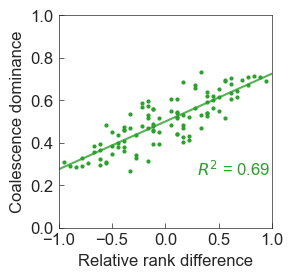

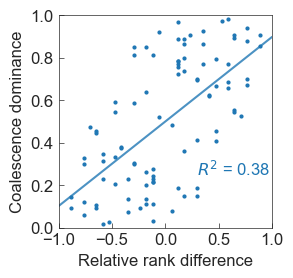

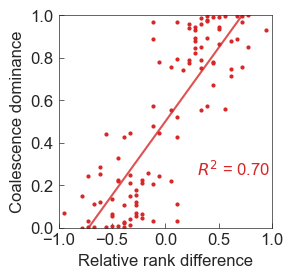

In [17]:
from scipy.stats import rankdata

## Hiearchy Plot with PH
mpl.rcParams['font.size'] = 12


def getDominanceMatrix(Variable2plot, Coalescence_data, Coal_IDX_list, Sub_IDX_list):
    N=len(Sub_IDX_list)
    matrix={Sub_IDX : {} for Sub_IDX in Sub_IDX_list }
    for SampleIDX in Coal_IDX_list:
        idx=np.where(Coalescence_data['SampleIDX']==SampleIDX)
        dominance1=Coalescence_data.iloc[idx][Variable2plot].tolist()[0]
        dominance2=1-dominance1
        subSampleIDX1=Coalescence_data.iloc[idx]["SampleIDX_Sub1"].tolist()[0]
        #subidx1=np.where(Sub_IDX_list==subSmapleIDX1)
        subSampleIDX2=Coalescence_data.iloc[idx]["SampleIDX_Sub2"].tolist()[0]


        #subidx2=np.where(Sub_IDX_list==subSmapleIDX2)
        matrix[subSampleIDX1].update({subSampleIDX2:dominance1})
        matrix[subSampleIDX2].update({subSampleIDX1:dominance2})
    for SampleIDX in Sub_IDX_list:
        matrix[SampleIDX].update({SampleIDX:0.5})
    
    return matrix



typeofplot="heatmap"
#'swarmpoint' #'swarmbox' # choose among 'swarmbox', 'swarmpoint', violin

Variable2plot_list=['SimilarityTo1_BC_3']
    #['Additivity3_3', 'Assymetricity_BC_3', 'Assymetricity_J_3', 'Assymetricity_JS_3',
       #'Assymetricity1_3', 'Assymetricity2_3', 'Assymetricity3_3']
        
M = [0.33, 0.66, 0.99]
species_pools = [12]
HueVariable='label'
hue_order = [0,1,2]
rep=1


colors=[sns.color_palette("tab10")[2], sns.color_palette("tab10")[0], sns.color_palette("tab10")[3]]
for i, medium in enumerate(['L','M','H']):
    fig, axs = plt.subplots(nrows=1, ncols=1, figsize=(70*mm, 70*mm), dpi=100, facecolor='w', edgecolor='k')

    Sub_IDX_list=Community_PermutateList("F", com_type, medium, "S", species_num, -1)
    Coal_IDX_list=Community_PermutateList("F", com_type, medium, "C", species_num, -1)

                #Sub_IDX_list=Nat_Sub_IDX['LN']
                #Coal_IDX_list=Nat_Coal_IDX['LN']


    matrix=getDominanceMatrix(Variable2plot, Coalescence_data, Coal_IDX_list, Sub_IDX_list)
    df = pd.DataFrame(matrix)
    df_sorted=df.sort_index(axis=1)
    df_sorted=df_sorted.sort_index(axis=0)
    competitive_scores = [1-np.mean(df.loc[row_col,:]) for row_col in df_sorted.index]

                # Sort rows and columns by competitive score
    sorted_idx = np.argsort(competitive_scores)
    df_sorted = df_sorted.iloc[sorted_idx, sorted_idx]
    df1=df_sorted

    com_columns=getCommunities(Communities_data,df_sorted.columns.tolist())
                
    competitive_scores = [1-np.mean(df.loc[row_col,:]) for row_col in df_sorted.index]
    competitive_scores = rankdata(competitive_scores)
    competitive_scores=competitive_scores/max(competitive_scores)
    
    x=[]
    y=[]
    
    #x=np.array(competitive_scores)
    #x_var='fieldPH7'
    #y=getCommunities(Communities_data,Sub_IDX_list).iloc[:][x_var]
    #y=getCommunities(Communities_data,df_sorted.columns.tolist())[x_var].tolist()
    count_agree=0
    count_disagree=0
    for (ii, jj) in  zip(*(np.where(~np.isnan(df_sorted.values)))):
        if ii==jj : 
            continue
        else : 
            x.append(competitive_scores[jj]-competitive_scores[ii])
            y.append(df_sorted.values[ii,jj])
            if int(np.sign(competitive_scores[jj]-competitive_scores[ii]))*np.int(np.sign(df_sorted.values[ii,jj]-0.5))==1:
                count_agree=count_agree+1
            else:
                count_disagree=count_disagree+1
    print(count_agree,count_disagree)
    x=np.array(x)
    y=np.array(y)
    slope, intercept = np.polyfit(x, y, 1)
    y_pred = slope * x + intercept
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r_squared = 1 - (ss_res / ss_tot)

    # Create a scatter plot of the data
    plt.scatter(x, y, color=colors[i], s=4)
    # Add the linear regression line to the plot
    plt.plot([-1,1], slope * np.array([-1,1]) + intercept, color=colors[i], alpha=0.8)
                # Add the R-squared value to the plot
    plt.annotate('$R^2$ = {:.2f}'.format(r_squared), xy=(0.05+0.6, 0.25), xycoords='axes fraction', fontsize=12, color=colors[i])

    plt.xlabel('Relative rank difference')
    plt.ylabel('Coalescence dominance')
    plt.xlim(-1,1)
    plt.ylim(0,1)

    
    plt.savefig(f'Figure/Fig_4-2_with_RelativeRankDifference_medium_{medium}_S12.svg', bbox_inches='tight')


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


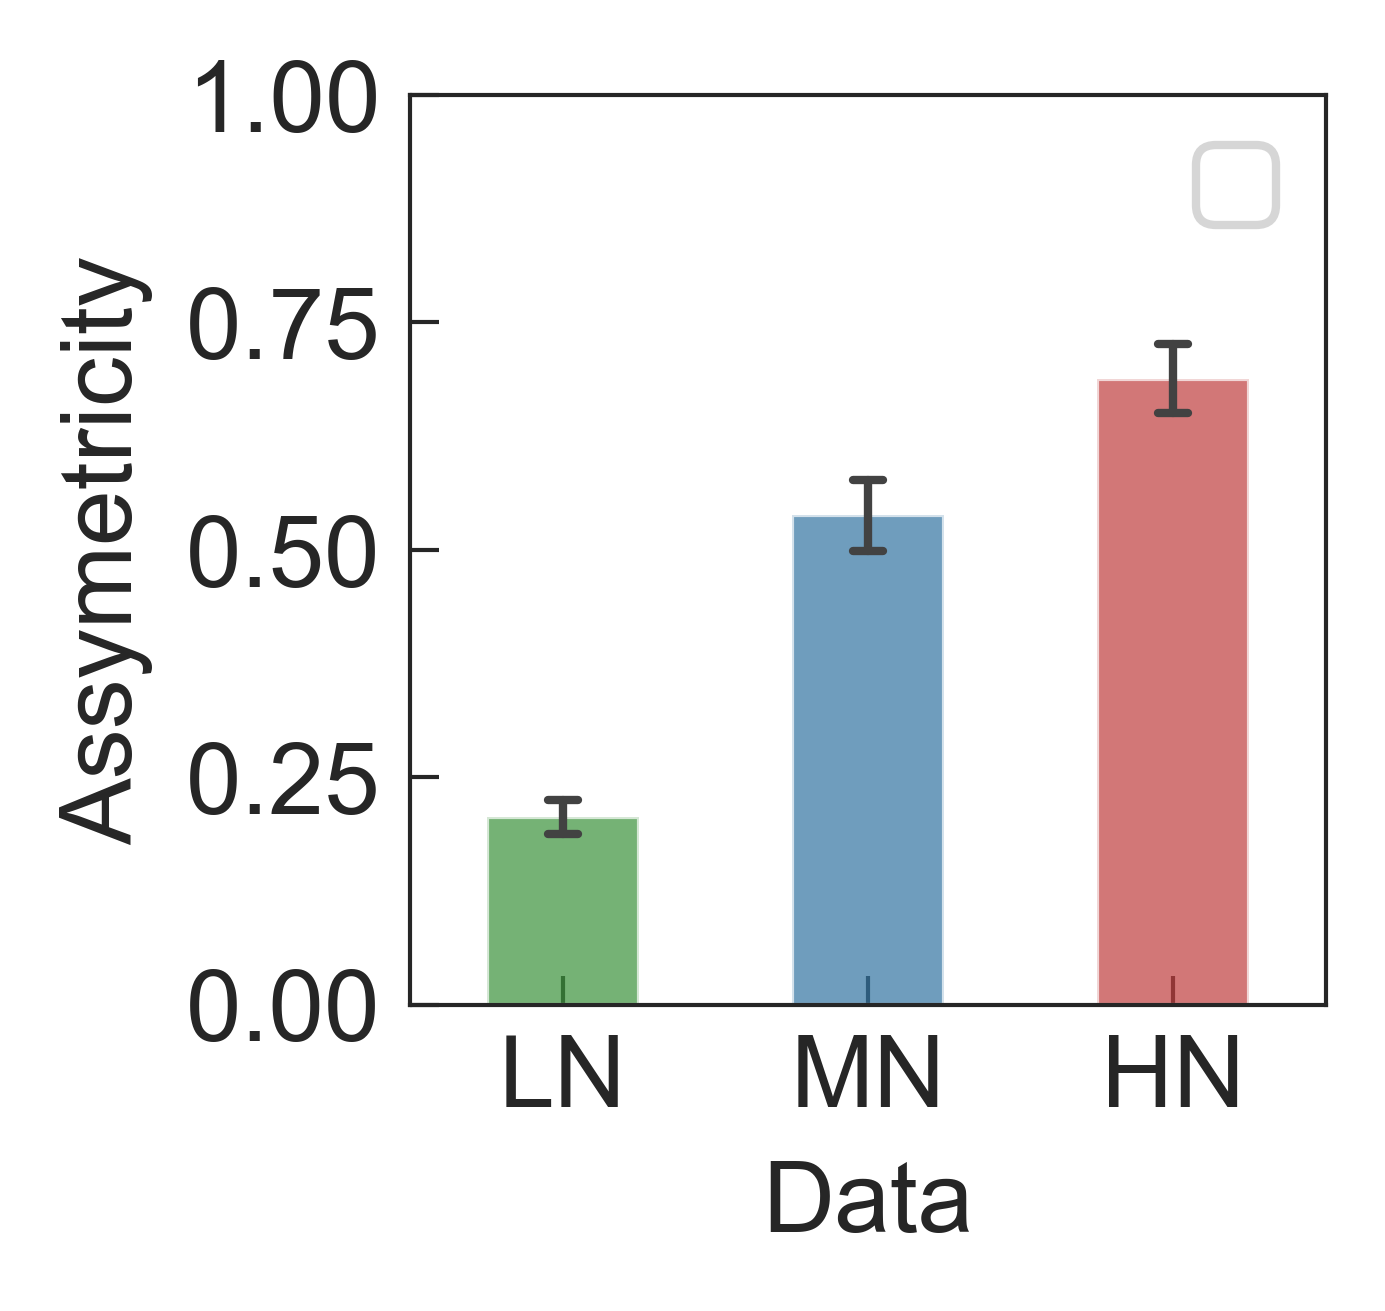

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


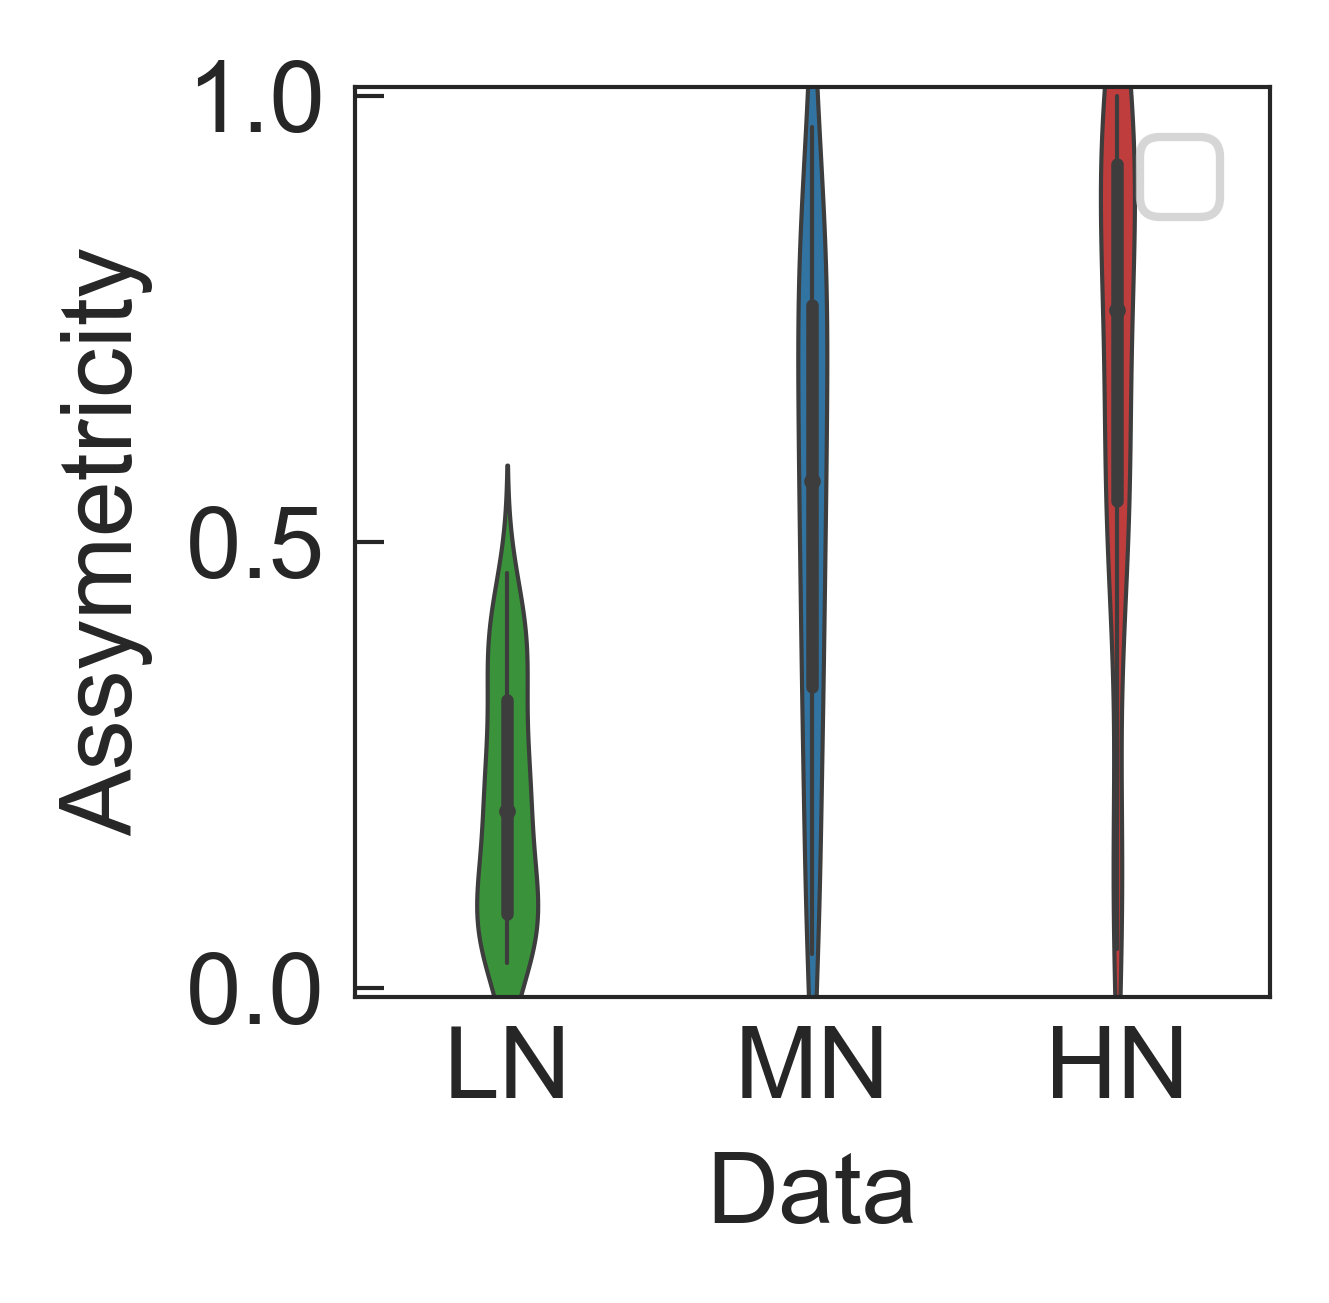

In [18]:
## Coal Figure 2. Plot every variable - swarm&box

typeofplot='swarmpoint' # choose among 'swarmbox', 'swarmpoint'
Variable2plot_list=[
       'Assymetricity_BC_5']


for Variable2plot in Variable2plot_list:
    Name2show = Variable2plot
    
    IDX_list = Syn_Coal_IDX["LN_12"]
    data = getCoalescence(Coalescence_data,IDX_list)
    data = data[Variable2plot]
    data1=data
    
    IDX_list = Syn_Coal_IDX["MN_12"]
    data = getCoalescence(Coalescence_data,IDX_list)
    data = data[Variable2plot]
    data2=data
    
    IDX_list = Syn_Coal_IDX["HN_12"]
    data = getCoalescence(Coalescence_data,IDX_list)
    data = data[Variable2plot]
    data3 = data

    
    combined_data = np.concatenate([data1, data2, data3])
    labels = ['LN'] * len(data1) + ['MN'] * len(data2) + ['HN'] * len(data3)
    df = pd.DataFrame({'Value': combined_data, 'Data': labels})

    # Convert the data into a DataFrame
    f, ax = plt.subplots(1, figsize=(50*mm,50*mm),facecolor='w', edgecolor='k')
    #sns.boxplot(x='Data', y='Value', data=df, order=['LN', 'MN', 'HN'], width=0.2, boxprops=dict(alpha=.7),  linewidth=.5, palette = {"LN": sns.color_palette("tab10")[2], "MN": sns.color_palette("tab10")[0], "HN": sns.color_palette("tab10")[3]})
    sns.barplot(x='Data', y='Value', data=df,  errorbar=('se'), order=['LN', 'MN', 'HN'], width=0.5, alpha=0.7, capsize=.1, errwidth=1,  linewidth=.5, palette = {"LN": sns.color_palette("tab10")[2], "MN": sns.color_palette("tab10")[0], "HN": sns.color_palette("tab10")[3]})
    plt.ylabel('Assymetricity')
    plt.ylim(0, 1.0)
    
    plt.legend()
    plt.show()
    f.savefig('Figure/Fig_3-1_NutrientVarying_BOXplot_'+str(Variable2plot)+'.svg', bbox_inches='tight')

    f, ax = plt.subplots(1, figsize=(50*mm,50*mm),facecolor='w', edgecolor='k')
    sns.violinplot(x='Data', y='Value', data=df, order=['LN', 'MN', 'HN'], width=0.2, boxprops=dict(alpha=.7),  linewidth=.5,   palette = {"LN": sns.color_palette("tab10")[2], "MN": sns.color_palette("tab10")[0], "HN": sns.color_palette("tab10")[3]})
    plt.ylabel('Assymetricity')
    plt.ylim(-0.01, 1.01)
    plt.legend()
    plt.show()
    f.savefig('Figure/Fig_3-1_NutrientVarying_Violinplot_'+str(Variable2plot)+'.svg', bbox_inches='tight')
    
    


#AllAbudnaces=getAbundance(Metadata['SampleIDX'])





In [19]:
Pairwise_Count_data_path="../../Postprocessed/PairwiseColonyCountings_processed_230915.xlsx"

Mono_Count_data={}
Pairwise_Count_data={}

Data=pd.read_excel(Pairwise_Count_data_path, sheet_name=0)
Data=np.transpose(np.array(Data.values[:,1:]))
Mono_Count_data["LN"]=Data
Data=pd.read_excel(Pairwise_Count_data_path, sheet_name=1)
Data=np.transpose(np.array(Data.values[:,1:]))
Mono_Count_data["MN"]=Data
Data=pd.read_excel(Pairwise_Count_data_path, sheet_name=2)
Data=np.transpose(np.array(Data.values[:,1:]))
Mono_Count_data["HN"]=Data

Data=pd.read_excel(Pairwise_Count_data_path, sheet_name=3)
Data=np.array(Data.values[:,1:])
Data_1=Data #This is the species for the first index
Data=pd.read_excel(Pairwise_Count_data_path, sheet_name=4)
Data=np.array(Data.values[:,1:])
Data_2=Data #This is the species for the second index
Data=np.stack([Data_1,Data_2])
Pairwise_Count_data["LN"]=Data

Data=pd.read_excel(Pairwise_Count_data_path, sheet_name=5)
Data=np.array(Data.values[:,1:])
Data_1=Data #This is the species for the first index
Data=pd.read_excel(Pairwise_Count_data_path, sheet_name=6)
Data=np.array(Data.values[:,1:])
Data_2=Data #This is the species for the second index
Data=np.stack([Data_1,Data_2])
Pairwise_Count_data["MN"]=Data

Data=pd.read_excel(Pairwise_Count_data_path, sheet_name=7)
Data=np.array(Data.values[:,1:])
Data_1=Data #This is the species for the first index
Data=pd.read_excel(Pairwise_Count_data_path, sheet_name=8)
Data=np.array(Data.values[:,1:])
Data_2=Data #This is the species for the second index
Data=np.stack([Data_1,Data_2])
Pairwise_Count_data["HN"]=Data

mediums=['LN', 'MN', 'HN']

data_flag_merged={}
data_p_ratio_merged={}
for medium_type in mediums:

    data_m=np.mean(Mono_Count_data[medium_type],1)
    data_p_1=Pairwise_Count_data[medium_type][0,:]
    data_p_2=Pairwise_Count_data[medium_type][1,:]
    data_flag=np.array([[None] * 12]*12)
    data_p_1_converted=np.array([[None] * 12]*12)
    data_p_2_converted=np.array([[None] * 12]*12)
    data_p_ratio=np.array([[None] * 12]*12)

    count=0
    for i in range(12):
        for j in range(12):
            if np.isnan(data_p_1[i,j]):
                data_flag[i,j]='case0' # No data
            else:
                if data_p_1[i,j]==1 and data_p_2[i,j]==0 :
                    #print(i,j,'case1') # species i dominates
                    data_flag[i,j]='case1'
                    data_p_1_converted[i,j]=1
                    data_p_2_converted[i,j]=0
                    data_p_ratio[i,j]=1

                elif data_p_1[i,j]==0 and data_p_2[i,j]==1 :
                    #print(i,j,'case2') # species j dominates
                    data_flag[i,j]='case2'
                    data_p_1_converted[i,j]=0
                    data_p_2_converted[i,j]=1
                    data_p_ratio[i,j]=0

                else:
                    #print(i,j,'case3') # species i, j coexists
                    data_flag[i,j]='case3'
                    data_p_1_converted[i,j]=data_p_1[i,j]/data_m[i]
                    data_p_2_converted[i,j]=data_p_2[i,j]/data_m[j]
                    data_p_ratio[i,j]=data_p_1_converted[i,j]/(data_p_1_converted[i,j]+data_p_2_converted[i,j])


                    
    data_flag_merged[medium_type]=data_flag
    data_p_ratio_merged[medium_type]=data_p_ratio

/var/folders/ml/8vkvr85554d3lhwlyxkmt_240000gn/T/ipykernel_34419/2120246439.py:82: RuntimeWarning: invalid value encountered in double_scalars
  data_p_ratio[i,j]=data_p_1_converted[i,j]/(data_p_1_converted[i,j]+data_p_2_converted[i,j])


In [20]:
ii=1
jj=2
data_flag_merged[medium_type][ii,jj]

'case2'

R² value: 0.08495482416937972


/var/folders/ml/8vkvr85554d3lhwlyxkmt_240000gn/T/ipykernel_34419/176499189.py:136: RuntimeWarning: invalid value encountered in double_scalars
  real_y=Sequence_composition[ii]/(Sequence_composition[ii]+Sequence_composition[jj])


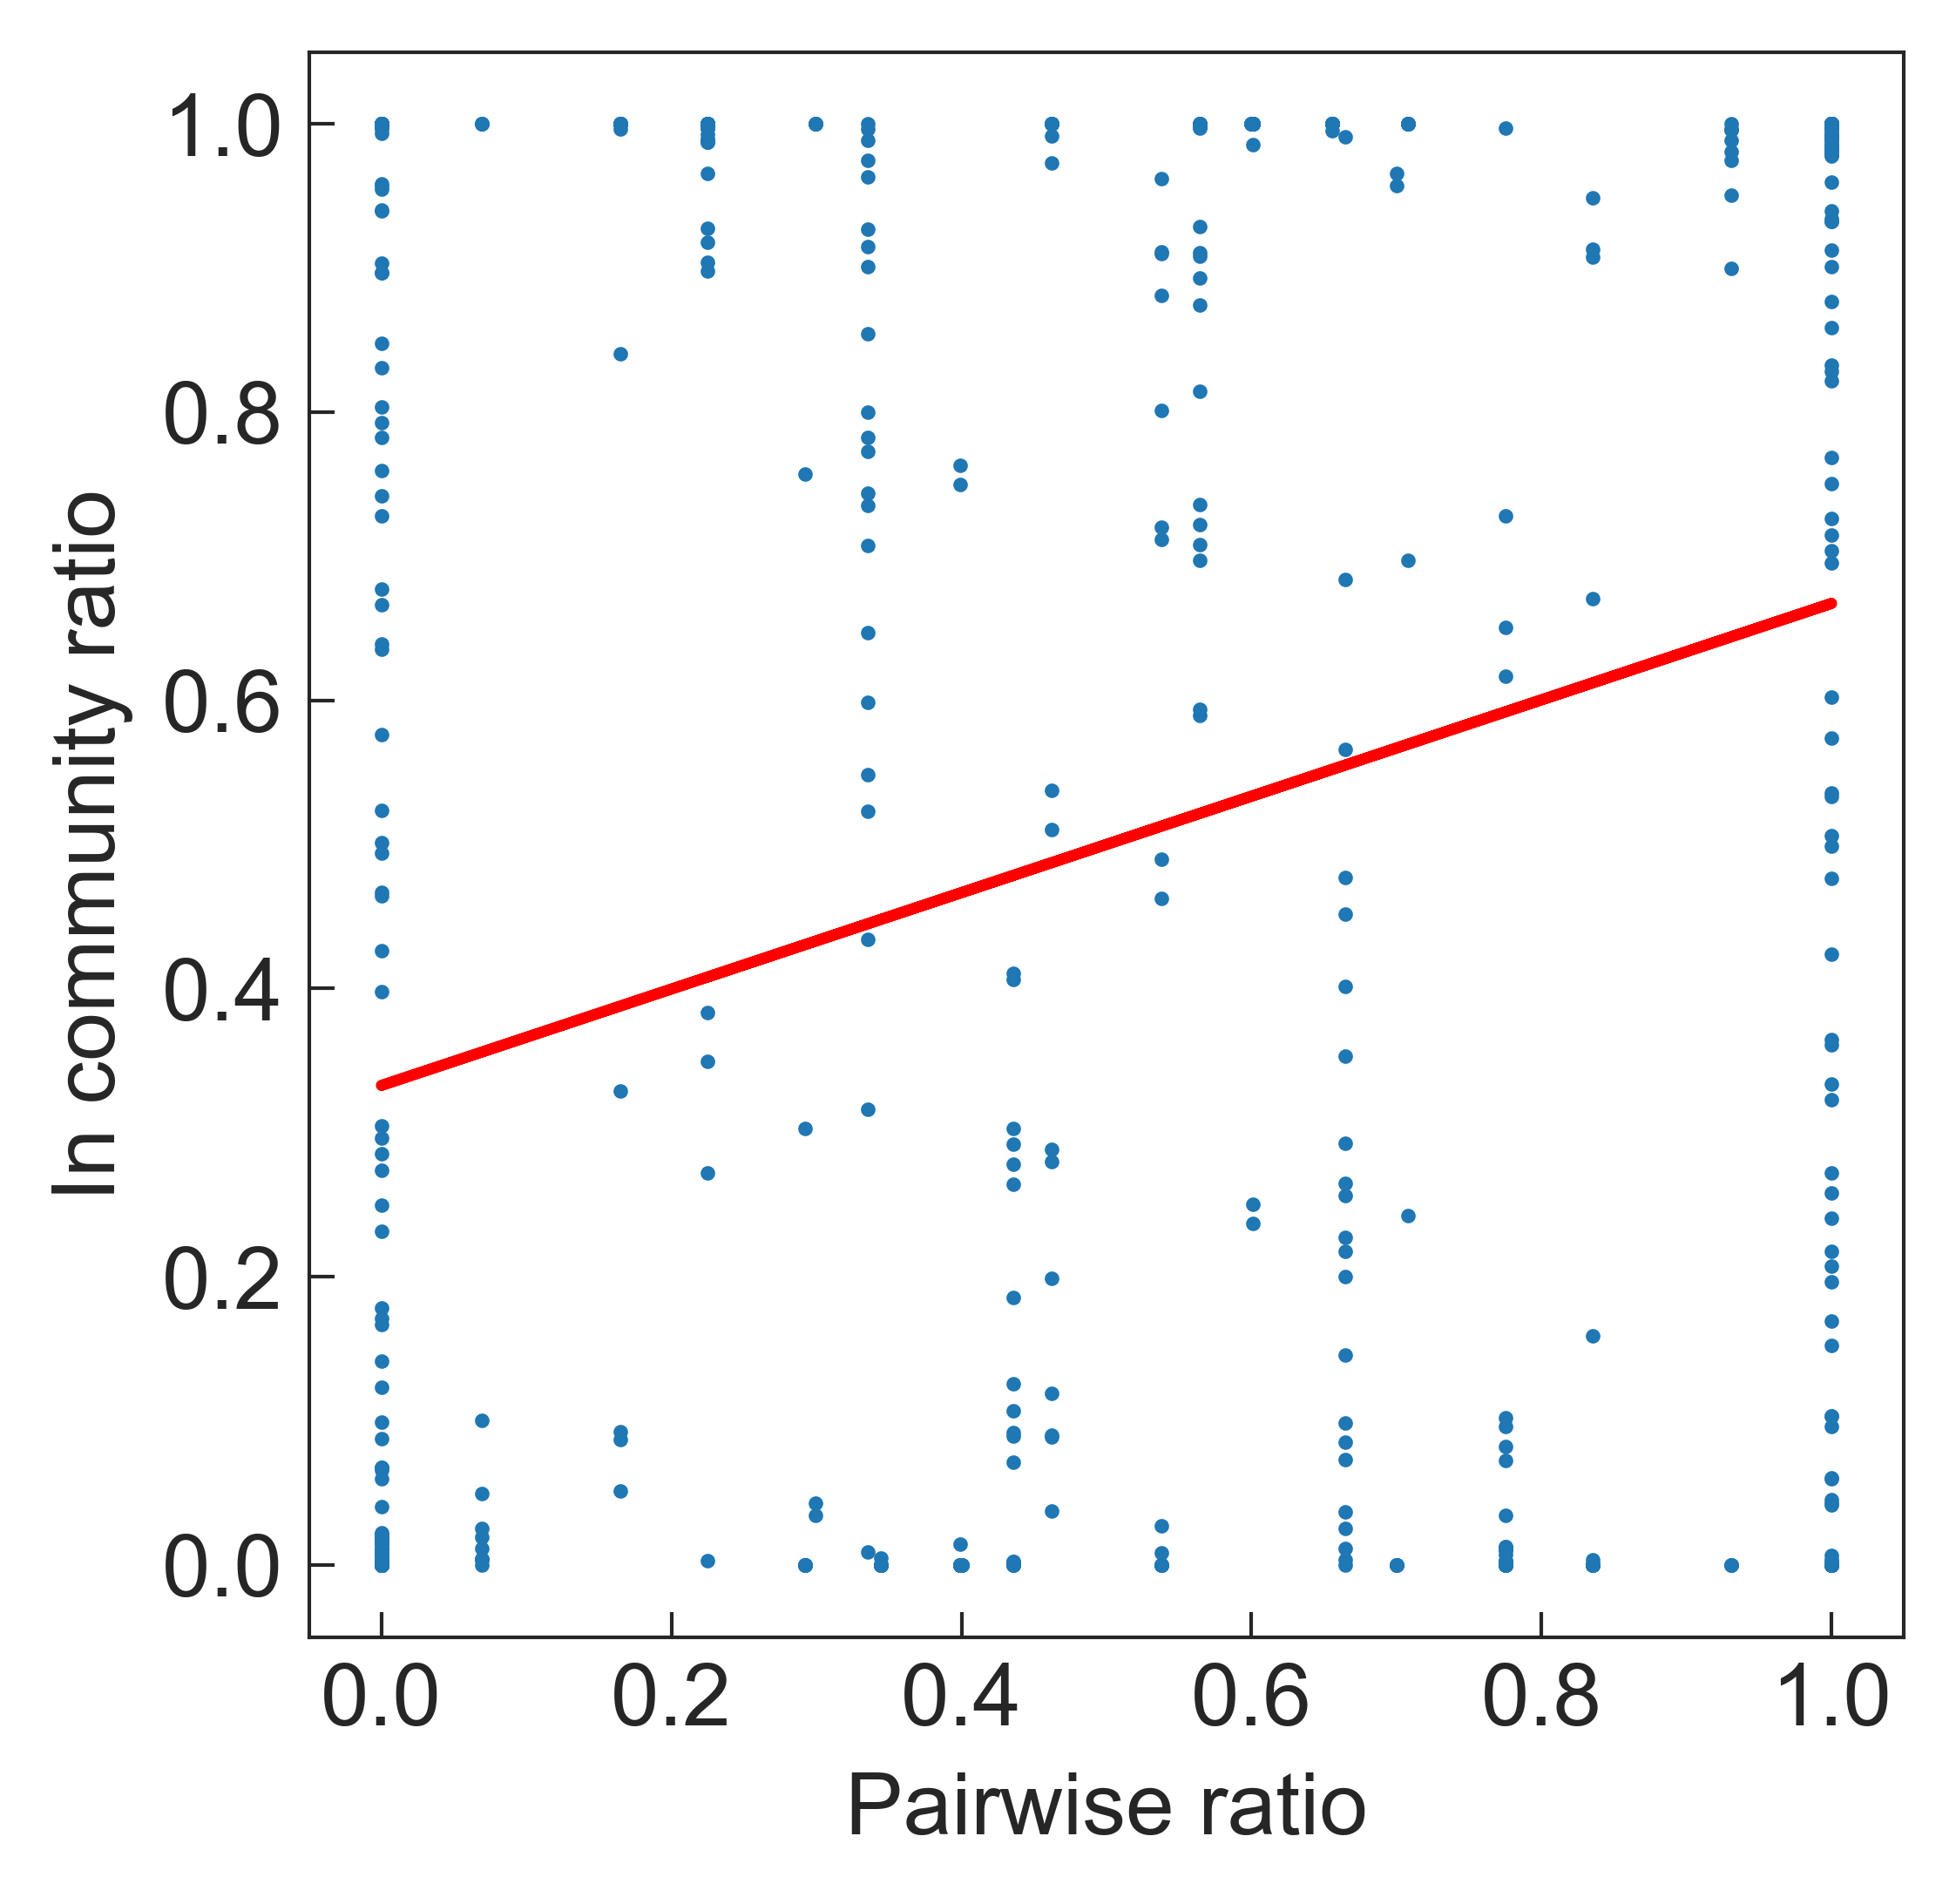

In [21]:
import itertools

def settingCoalSubASVlist():
    Top12ASV_included=[[1,3,7],[2,4],[3,5,6,7],[4,9],[1,5,7],[6],[5,7],[2,7],[1,2,7,9]]

    S6_index = [
    [1],[2],[3],[4],[5],[6],[7],[8],[9]
    ]

    S12_index = [
        (1, 3),
        (3, 4),
        (5, 9),
        (4, 9),
        (6, 7),
        (5, 6),
        (1, 2),
        (7, 8),
        (2, 8),
    ]

    S24_index = [
        (1, 2, 3, 4),
        (5, 6, 7, 8),
        (1, 3, 5, 9),
        (2, 6, 7, 8),
        (1, 3, 5, 6),
        (4, 7, 8, 9),
        (2, 5, 8, 9),
        (3, 4, 6, 7),
        (1, 2, 5, 9),
        (3, 4, 7, 8),
        (1, 2, 7, 8),
        (4, 5, 6, 9),
    ]
    
    Coal_recipe = [
    [1, 1, 2],
    [2, 1, 3],
    [3, 1, 7],
    [4, 2, 5],
    [5, 2, 8],
    [6, 3, 4],
    [7, 3, 8],
    [8, 4, 5],
    [9, 4, 9],
    [10, 5, 6],
    [11, 5, 9],
    [12, 6, 7],
    [13, 6, 9],
    [14, 7, 8],
    [15, 10, 12],
    [16, 10, 13],
    [17, 10, 14],
    [18, 10, 15],
    [19, 10, 17],
    [20, 10, 18],
    [21, 11, 12],
    [22, 11, 14],
    [23, 11, 15],
    [24, 11, 16],
    [25, 11, 17],
    [26, 11, 18],
    [27, 12, 14],
    [28, 12, 16],
    [29, 12, 17],
    [30, 12, 18],
    [31, 13, 14],
    [32, 13, 15],
    [33, 13, 16],
    [34, 13, 17],
    [35, 13, 18],
    [36, 14, 16],
    [37, 14, 18],
    [38, 15, 16],
    [39, 15, 17],
    [40, 15, 18],
    [41, 16, 17],
    [42, 19, 20],
    [43, 21, 22],
    [44, 23, 24],
    [45, 25, 26],
    [46, 27, 28],
    [47, 29, 30]]

    S_index_merged=S6_index+S12_index+S24_index

    Sub_ASV_list=[]
    for i in range(30):
        Sub_ASV_list.append(np.unique(list(itertools.chain(*[Top12ASV_included[j-1] for j in S_index_merged[i]]))))

    Coal_ASV_list=[]
    for i in range(47):
        Coal_ASV_list.append(np.unique(Sub_ASV_list[Coal_recipe[i][1]-1].tolist()+Sub_ASV_list[Coal_recipe[i][2]-1].tolist()))
    return Sub_ASV_list, Coal_ASV_list

Sub_ASV_list, Coal_ASV_list=settingCoalSubASVlist()


##Get a relative abundances
##

medium_type='MN'
medium=medium_type[0]

species_num=12
com_type="S"
rep=-1

#Sub_IDX_list=Community_PermutateList("F", com_type, medium, "S", species_num, rep)
#Coal_IDX_list=Community_PermutateList("F", com_type, medium, "C", species_num, rep)

IDX_list=Community_PermutateList("F", com_type, medium, "C", species_num, rep)
IDX_list_=np.squeeze([np.where(Processed_sequences_synthetic['SampleIDX']==x) for x in IDX_list])
df=Processed_sequences_synthetic.iloc[IDX_list_]
IDX_list_=np.squeeze([np.where(Metadata['SampleIDX']==x) for x in IDX_list])
df2=Metadata.iloc[IDX_list_]
plt.figure(1, figsize=(100*mm,100*mm))

x=[]
y=[]
for i in range(len(df)):
    Sequence_composition=df.iloc[i,1:]
    if df2.iloc[i,1:]['CoalescenceType']=='S':
        ASV_list=Sub_ASV_list[df2.iloc[i,1:]['CommunityIDX']-1]
    elif df2.iloc[i,1:]['CoalescenceType']=='C':
        ASV_list=Coal_ASV_list[df2.iloc[i,1:]['CommunityIDX']-1]
    for i in range(len(ASV_list)):
        for j in range(i + 1, len(ASV_list)):
            ii = ASV_list[i]-1
            jj = ASV_list[j]-1
            if data_flag_merged[medium_type][ii,jj]=='case0':
                continue
            else : 
                pred_y=data_p_ratio_merged[medium_type][ii,jj]
                real_y=Sequence_composition[ii]/(Sequence_composition[ii]+Sequence_composition[jj])
                if Sequence_composition[ii]<0.1 and Sequence_composition[jj]<0.1:
                    continue
                else:
                    x.append(pred_y)
                    y.append(real_y)
                    x.append(1-pred_y)
                    y.append(1-real_y)

x=np.array(x)
y=np.array(y)
plt.scatter(x,y, s=1)
    #data_p_ratio_merged['LN']
m, b = np.polyfit(x, y, 1)


model = LinearRegression()
model.fit(x.reshape(-1, 1), y)
y_pred = model.predict(x.reshape(-1, 1))
r_squared = r2_score(y, y_pred)
print(f'R² value: {r_squared}')
xlabel('Pairwise ratio')
ylabel('In community ratio')
regression_line = model.coef_ * x + model.intercept_
plt.plot(x, regression_line, label='Linear Fit', color='red')


In [22]:
model.coef_ * np.array([-0.1,1.1])

array([-0.0334509 ,  0.36795989])

/var/folders/ml/8vkvr85554d3lhwlyxkmt_240000gn/T/ipykernel_34419/288242734.py:47: RuntimeWarning: invalid value encountered in double_scalars
  real_y=Sequence_composition[ii]/(Sequence_composition[ii]+Sequence_composition[jj])
/var/folders/ml/8vkvr85554d3lhwlyxkmt_240000gn/T/ipykernel_34419/288242734.py:47: RuntimeWarning: invalid value encountered in double_scalars
  real_y=Sequence_composition[ii]/(Sequence_composition[ii]+Sequence_composition[jj])
/var/folders/ml/8vkvr85554d3lhwlyxkmt_240000gn/T/ipykernel_34419/288242734.py:47: RuntimeWarning: invalid value encountered in double_scalars
  real_y=Sequence_composition[ii]/(Sequence_composition[ii]+Sequence_composition[jj])
/var/folders/ml/8vkvr85554d3lhwlyxkmt_240000gn/T/ipykernel_34419/288242734.py:47: RuntimeWarning: invalid value encountered in double_scalars
  real_y=Sequence_composition[ii]/(Sequence_composition[ii]+Sequence_composition[jj])
/var/folders/ml/8vkvr85554d3lhwlyxkmt_240000gn/T/ipykernel_34419/288242734.py:47: Runtim

R² value: 0.026201043462171336
R² value: 0.002448841990009498
R² value: 0.24703697037506644
R² value: 0.08495482416937972
R² value: 0.13311841395441015
R² value: 0.2758502609534297


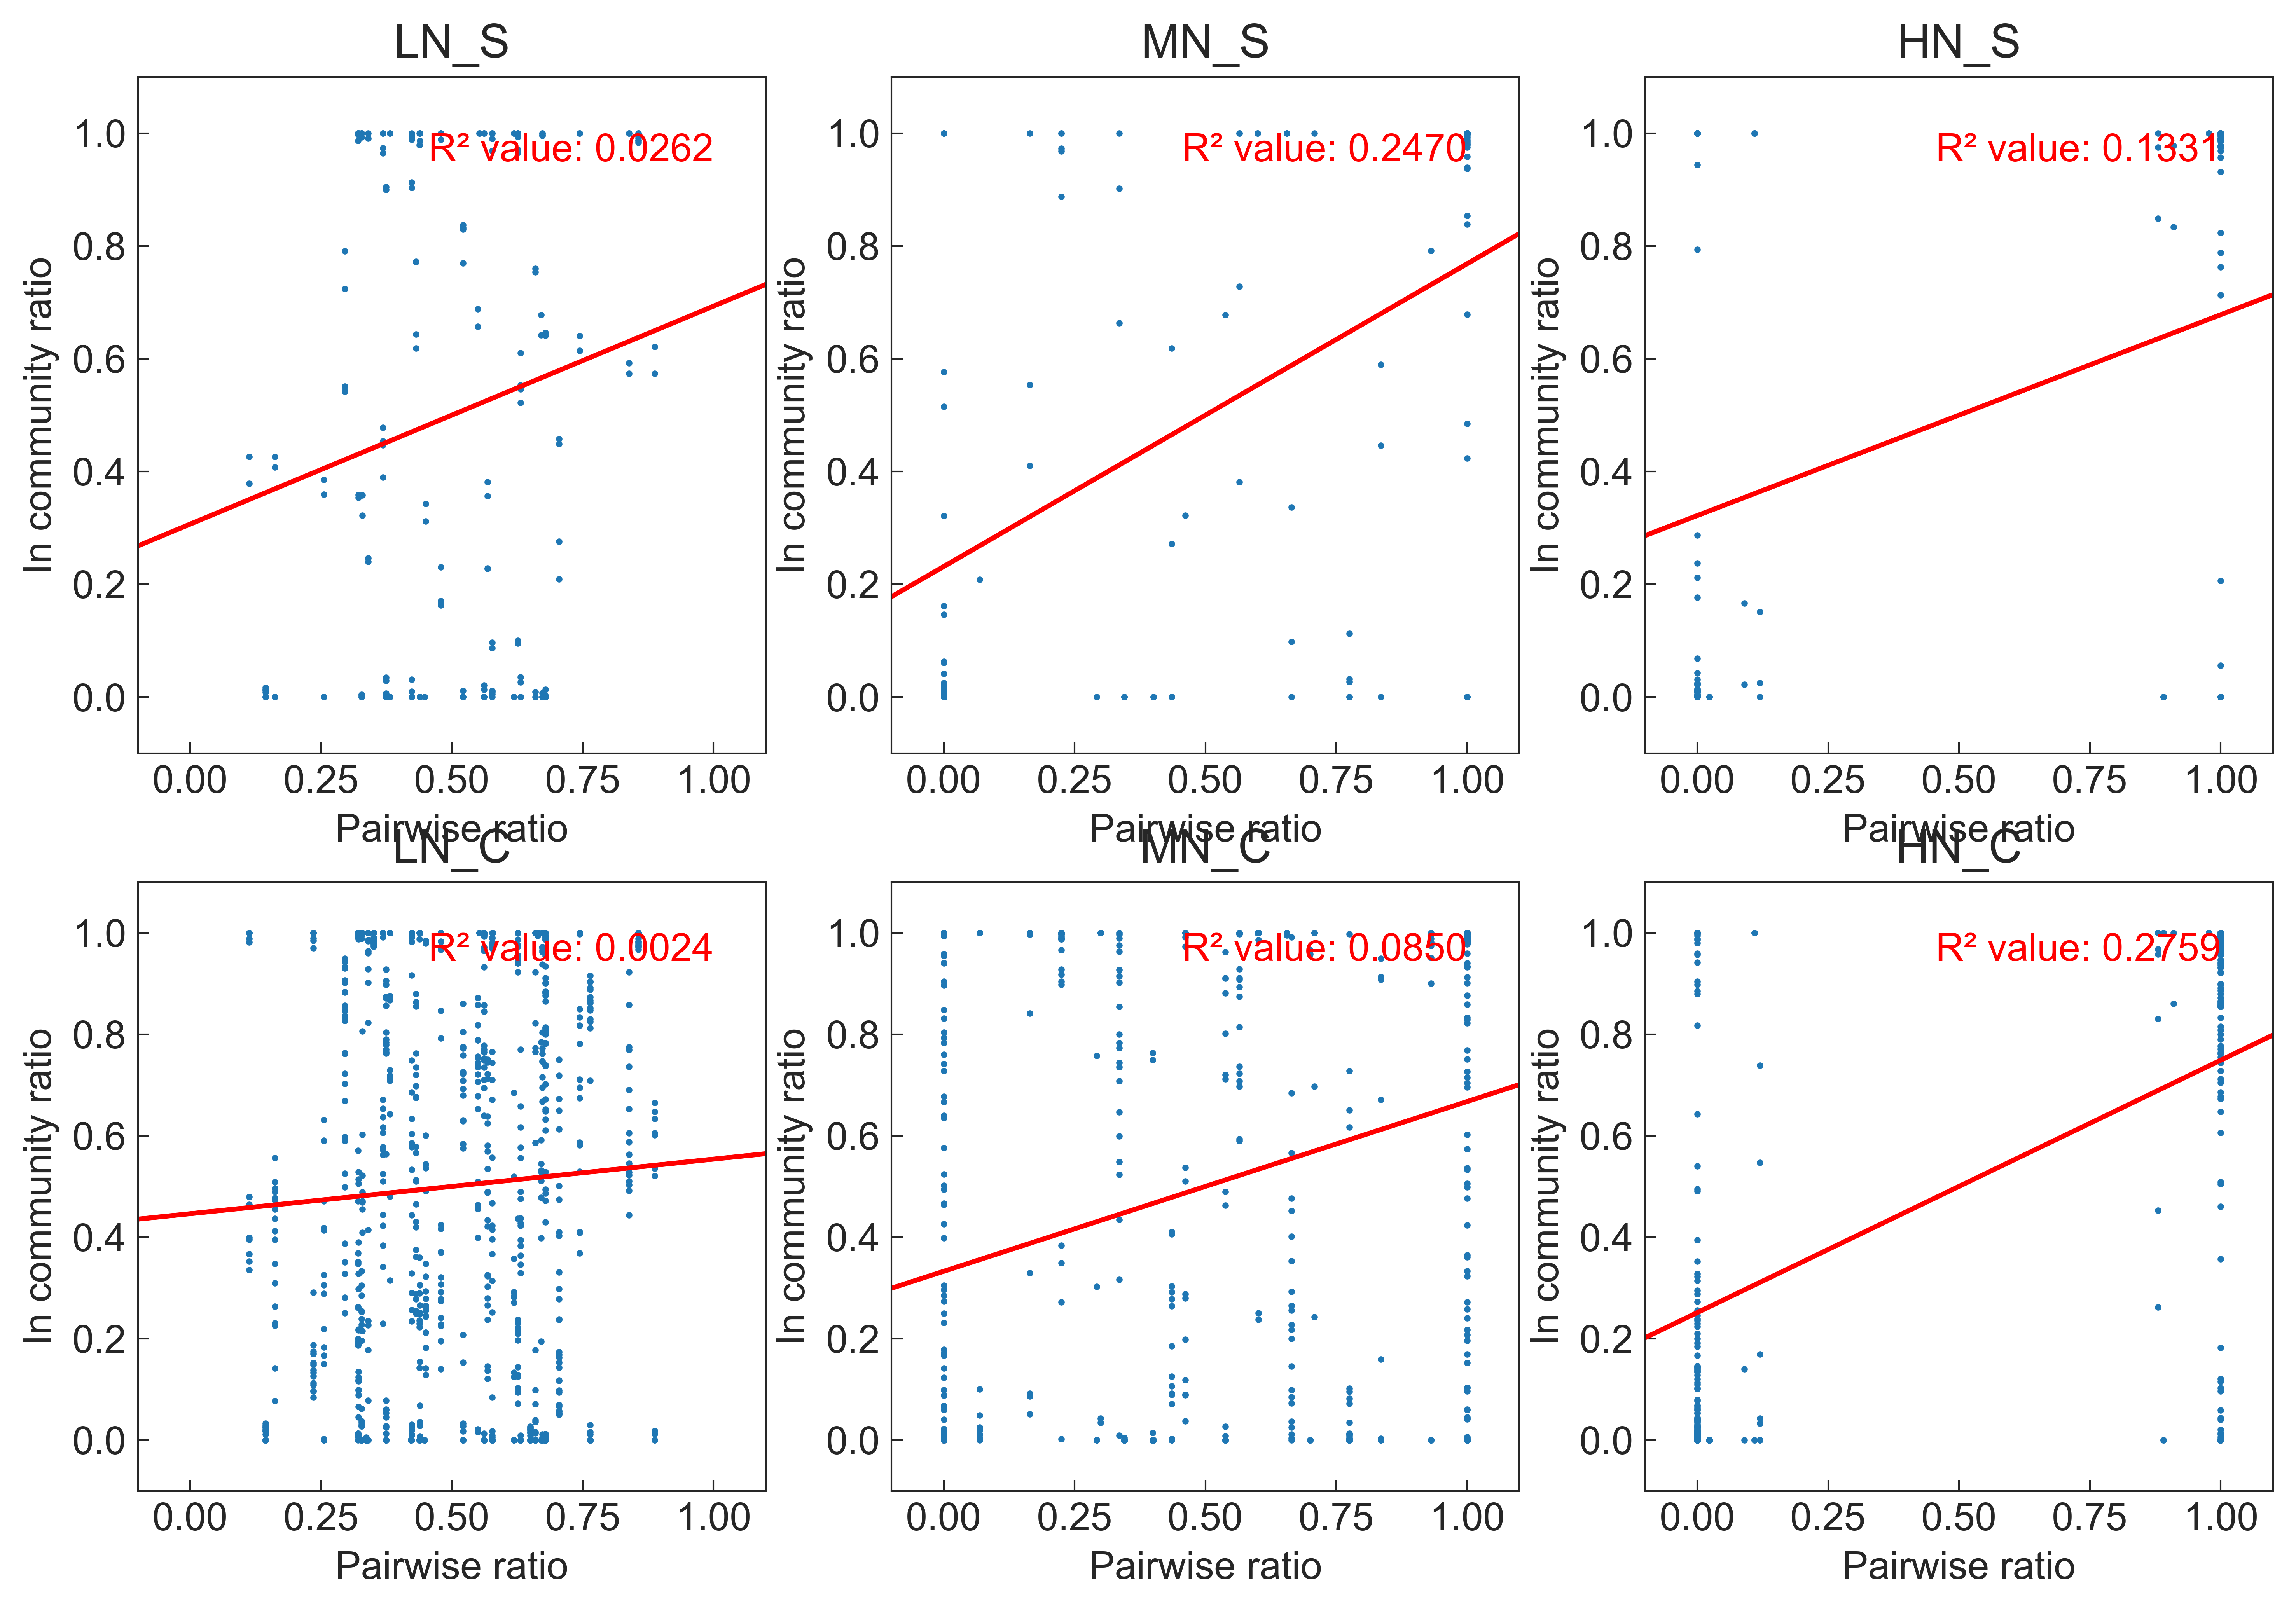

In [23]:
mediums=['LN','MN','HN']
comm_types=['S','C']
orders=[1,2]
alphas=np.logspace(-5, -0, num=50)
betas=np.logspace(-3, 3, num=60)

fig=plt.figure(figsize=(300*mm,200*mm))
gs = GridSpec(2, 3, width_ratios=[1,1,1], height_ratios=[1,0.9])
    

for kk, medium_type in enumerate(mediums):
    for tt, comm_type in enumerate(comm_types):

        medium=medium_type[0]
        species_num=12
        com_type="S"
        rep=-1

        #Sub_IDX_list=Community_PermutateList("F", com_type, medium, "S", species_num, rep)
        #Coal_IDX_list=Community_PermutateList("F", com_type, medium, "C", species_num, rep)

        IDX_list=Community_PermutateList("F", com_type, medium, comm_type, species_num, rep)
        IDX_list_=np.squeeze([np.where(Processed_sequences_synthetic['SampleIDX']==x) for x in IDX_list])
        df=Processed_sequences_synthetic.iloc[IDX_list_]
        IDX_list_=np.squeeze([np.where(Metadata['SampleIDX']==x) for x in IDX_list])
        df2=Metadata.iloc[IDX_list_]
        x=[]
        y=[]
        for i in range(len(df)):

            Sequence_composition=df.iloc[i,1:]
            if df2.iloc[i,1:]['CoalescenceType']=='S':
                ASV_list=Sub_ASV_list[df2.iloc[i,1:]['CommunityIDX']-1]
            elif df2.iloc[i,1:]['CoalescenceType']=='C':
                ASV_list=Coal_ASV_list[df2.iloc[i,1:]['CommunityIDX']-1]



            for i in range(len(ASV_list)):
                for j in range(i + 1, len(ASV_list)):
                    ii = ASV_list[i]-1
                    jj = ASV_list[j]-1
                    if data_flag_merged[medium_type][ii,jj]=='case0':
                        continue
                    else : 
                        pred_y=data_p_ratio_merged[medium_type][ii,jj]
                        real_y=Sequence_composition[ii]/(Sequence_composition[ii]+Sequence_composition[jj])
                        if Sequence_composition[ii]<0.1 and Sequence_composition[jj]<0.1:
                            continue
                        else:
                            x.append(pred_y)
                            y.append(real_y)
                            x.append(1-pred_y)
                            y.append(1-real_y)

        ax = fig.add_subplot(gs[tt,kk])

        x=np.array(x)
        y=np.array(y)
        ax.scatter(x,y, s=1)
            #data_p_ratio_merged['LN']
        m, b = np.polyfit(x, y, 1)


        model = LinearRegression()
        model.fit(x.reshape(-1, 1), y)
        y_pred = model.predict(x.reshape(-1, 1))
        r_squared = r2_score(y, y_pred)
        print(f'R² value: {r_squared}')
        xlabel('Pairwise ratio')
        ylabel('In community ratio')
        regression_line = model.coef_ * np.array([-0.1,1.1]) + model.intercept_
        plt.plot(np.array([-0.1,1.1]), regression_line, label='Linear Fit', color='red')
        plt.text(1, 1, f'R² value: {r_squared :.4f}', ha='right', va='top', color='red')
        plt.xlim(-0.1, 1.1)
        plt.ylim(-0.1, 1.1)
        plt.title(medium_type+'_'+comm_type)


        
plt.savefig('Figure/Fig_5-2_LinearRegression_hyperparamterSearch.svg', bbox_inches='tight')
plt.show()

In [24]:
y

array([0.01437721, 0.98562279, 0.00238127, 0.99761873, 1.        ,
       0.        , 1.        , 0.        , 0.993937  , 0.006063  ,
       1.        , 0.        , 0.06370699, 0.93629301, 0.01998141,
       0.98001859, 0.99622107, 0.00377893, 1.        , 0.        ,
       0.99223712, 0.00776288, 1.        , 0.        , 0.9705597 ,
       0.0294403 , 1.        , 0.        , 1.        , 0.        ,
       1.        , 0.        , 1.        , 0.        , 0.14251471,
       0.85748529, 1.        , 0.        , 0.96564417, 0.03435583,
       0.95928815, 0.04071185, 0.74405548, 0.25594452, 1.        ,
       0.        , 1.        , 0.        , 1.        , 0.        ,
       1.        , 0.        , 1.        , 0.        , 1.        ,
       0.        , 1.        , 0.        , 1.        , 0.        ,
       1.        , 0.        , 1.        , 0.        , 1.        ,
       0.        , 0.89767442, 0.10232558, 0.19153159, 0.80846841,
       1.        , 0.        , 1.        , 0.        , 1.     

In [25]:
len(x), sum((x>0.5) & (y>0.5)), sum((x<0.5) & (y<0.5))

(578, 223, 223)

In [26]:
len(x), sum((x>0.5) & (y>0.5)), sum((x<0.5) & (y<0.5))

(578, 223, 223)

In [27]:
114+286

400

In [28]:
Sub_ASV_list[Coal_recipe[i][2]].tolist()

NameError: name 'Coal_recipe' is not defined

In [ ]:
i=15
np.unique(list(itertools.chain(*[Top12ASV_included[j-1] for j in S_index_merged[i]])))


In [ ]:
Coalescence_recipe

In [ ]:
## First choice : Include certain species number only

# Set community Variable
Variable2plot='SimilarityTo1_BC_5'
medium="H"
species_num=12
com_type="S"
rep=-1

# Set Hyper parameter Variable
alphas=np.logspace(-5, -0, num=50)
betas=np.logspace(-3, 3, num=60)
order=1
preprocess='Normalize' ##'Basic', 'Normalize', 'ArcTanh'


##
Sub_IDX_list=Community_PermutateList("F", com_type, medium, "S", species_num, rep)
Coal_IDX_list=Community_PermutateList("F", com_type, medium, "C", species_num, rep)

matrix=getDominanceMatrix(Variable2plot, Coalescence_data, Coal_IDX_list, Sub_IDX_list)
df = pd.DataFrame(matrix)
df_sorted=df.sort_index(axis=1)
df_sorted=df_sorted.sort_index(axis=0)
competitive_scores = [1-np.mean(df.loc[row_col,:]) for row_col in df_sorted.index]

# Sort rows and columns by competitive score
sorted_idx = np.argsort(competitive_scores)[::-1]
df_sorted = df_sorted.iloc[sorted_idx, sorted_idx]
competitive_scores_sorted = [1-np.mean(df_sorted.loc[row_col,:]) for row_col in df_sorted.index]
competitive_scores_sorted

#getAbundance(getIDX(Processed_sequences_synthetic, IDX))
IDX_list=df_sorted.keys()
x=np.array(getAbundance_fromList(Processed_sequences_synthetic,df_sorted.keys()))
y=np.array(competitive_scores_sorted)

mean_train_mse={}
mean_test_mse={}
for alpha in alphas:
    for beta in betas:
        communityIDX_list, train_mse_list, test_mse_list = EstimateErrorLassoRegression(IDX_list, x, y, order=order, alpha=alpha, beta=beta, preprocess=preprocess)        
        mean_train_mse[(alpha, beta)] = np.mean(train_mse_list)
        mean_test_mse[(alpha, beta)] = np.mean(test_mse_list)
        print(f"Processing for alpha = {alpha} and beta = {beta} is done. Result: {np.mean(train_mse_list),  np.mean(test_mse_list)}")

TrialTitle=f"Partial_SpeciesNum_{species_num}_Medium_{medium}_Order_{order}_Preprocess_{preprocess}"
with open('Data/'+TrialTitle+'_mean_train_mse.pkl', 'wb') as f:
    pickle.dump(mean_train_mse, f)

with open('Data/'+TrialTitle+'_mean_test_mse.pkl', 'wb') as f:
    pickle.dump(mean_test_mse, f)
                                                
# To load the pickled data back
with open('Data/'+TrialTitle+'_mean_test_mse.pkl', 'rb') as f:
    loaded_results = pickle.load(f)
    
print(loaded_results)

In [ ]:

filename='Partial_SpeciesNum_12_Medium_M_Order_2_Preprocess_Normalize_mean_test_mse'
with open('Data/'+filename+'.pkl', 'rb') as f:
    loaded_results = pickle.load(f)
    
# Create a grid of alpha and beta values
alpha_grid, beta_grid = np.meshgrid(alphas, betas)

loss_values=np.zeros([len(alphas), len(betas)])

for i, alpha in enumerate(alphas):
    for j, beta in enumerate(betas):
        loss_values[i,j]=loaded_results[(alpha,beta)]


centered_offset=1
loss_values_centered=loss_values[centered_offset:-centered_offset,centered_offset:-centered_offset]
min_indices = np.unravel_index(np.argmin(loss_values_centered), loss_values_centered.shape)
global_min_alpha = alphas[centered_offset+min_indices[0]]
global_min_beta = betas[centered_offset+min_indices[1]]
global_min_loss = loss_values_centered[min_indices]

print(global_min_alpha,global_min_beta)

levels = np.logspace(np.log10(np.min(loss_values)), 0.01, 20)

# Create a contour plot
plt.figure(figsize=(80*mm,60*mm))
contour = plt.contourf(alpha_grid, beta_grid, np.minimum(loss_values.T,1.001), levels=levels, cmap='jet_r', norm=LogNorm())
plt.scatter(global_min_alpha, global_min_beta, color='red', marker='.', s=20)
plt.text(global_min_alpha+2e-5, global_min_beta+2e-5, f'Min Error: {global_min_loss:.4f}', color='red', fontsize=10, ha='left', va='bottom')

plt.colorbar(contour, label='Loss')
plt.xscale('log')  # Set x-axis to log scale
plt.yscale('log')  # Set y-axis to log scale
plt.xlabel('Alpha (log scale)')
plt.ylabel('Beta (log scale)')
plt.title('Contour Plot of Loss Function')
plt.grid(True)
plt.show()

In [ ]:
mediums=['L','M','H']
orders=[1,2]
alphas=np.logspace(-5, -0, num=50)
betas=np.logspace(-3, 3, num=60)

fig=plt.figure(figsize=(450*mm,220*mm))
gs = GridSpec(2, 3, width_ratios=[1,1,1], height_ratios=[1,0.9])
    
for ii, medium in enumerate(mediums):
    for jj, order in enumerate(orders):
        filename=f'Partial_SpeciesNum_12_Medium_{medium}_Order_{order}_Preprocess_Normalize_mean_test_mse'
        with open('Data/'+filename+'.pkl', 'rb') as f:
            loaded_results = pickle.load(f)

        # Create a grid of alpha and beta values
        alpha_grid, beta_grid = np.meshgrid(alphas, betas)

        loss_values=np.zeros([len(alphas), len(betas)])

        for i, alpha in enumerate(alphas):
            for j, beta in enumerate(betas):
                loss_values[i,j]=loaded_results[(alpha,beta)]


        centered_offset=10
        loss_values_centered=loss_values[centered_offset:-centered_offset,centered_offset:-centered_offset]
        min_indices = np.unravel_index(np.argmin(loss_values_centered), loss_values_centered.shape)
        global_min_alpha = alphas[centered_offset+min_indices[0]]
        global_min_beta = betas[centered_offset+min_indices[1]]
        global_min_loss = loss_values_centered[min_indices]

        print(f'Min error condtion for {medium} and {order} is {global_min_alpha,global_min_beta}, error : {global_min_loss}')

        levels = np.logspace(np.log10(np.min(loss_values)), 0, 20)
        ax = fig.add_subplot(gs[jj, ii])
        # Create a contour plot
        contour = ax.contourf(alpha_grid, beta_grid, np.minimum(loss_values.T,1), levels=levels, cmap='jet_r', norm=LogNorm())
        ax.scatter(global_min_alpha, global_min_beta, color='red', marker='.', s=20)
        ax.text(global_min_alpha+2e-5, global_min_beta+2e-5, f'Min Error: {global_min_loss:.4f}', color='red', fontsize=10, ha='left', va='bottom')

        plt.colorbar(contour, label='Loss')
        plt.xscale('log')  # Set x-axis to log scale
        plt.yscale('log')  # Set y-axis to log scale
        plt.xlabel('Alpha (log scale)')
        plt.ylabel('Beta (log scale)')
        plt.title(f'{medium}N-order:{order}')
        plt.grid(True)
plt.savefig('Figure/Fig_5-1_LinearRegression_hyperparamterSearch.svg', bbox_inches='tight')
plt.show()


In [ ]:
Condition='HN_2'

if Condition== 'LN_1':
    medium="L"
    species_num=12
    com_type="S"
    rep=-1
    order=1
    #alpha = 2.559547922699533e-05
    #beta = 791.2342618981327
    alpha =0.00010481131341546853
    beta = 0.1726983290659436       
elif Condition == 'LN_2':
    medium="L"
    species_num=12
    com_type="S"
    rep=-1
    order=2
    alpha =0.000868511373751353
    beta = 1.4208308325339223
elif Condition == 'MN_1':
    medium="M"
    species_num=12
    com_type="S"
    rep=-1
    order=1
    alpha = 0.7906043210907702
    beta = 245.37511066398218
elif Condition =='MN_2':
    medium="M"
    species_num=12
    com_type="S"
    rep=-1
    order=2
    alpha = 0.09540954763499944
    beta=  60.20894493336138
elif Condition == 'HN_1':
    medium="H"
    species_num=12
    com_type="S"
    rep=-1
    order=1
    alpha = 0.1206792640639329
    beta= 791.2342618981327
elif Condition == 'HN_2':
    medium="H"
    species_num=12
    com_type="S"
    rep=-1
    order=2
    alpha = 0.00013257113655901095
    beta= 1.4208308325339223

# Set Hyper parameter Variable
preprocess='Normalize' ##'Basic', 'Normalize', 'ArcTanh'


##
Sub_IDX_list=Community_PermutateList("F", com_type, medium, "S", species_num, rep)
Coal_IDX_list=Community_PermutateList("F", com_type, medium, "C", species_num, rep)

matrix=getDominanceMatrix(Variable2plot, Coalescence_data, Coal_IDX_list, Sub_IDX_list)
df = pd.DataFrame(matrix)
df_sorted=df.sort_index(axis=1)
df_sorted=df_sorted.sort_index(axis=0)
competitive_scores = [1-np.mean(df.loc[row_col,:]) for row_col in df_sorted.index]

# Sort rows and columns by competitive score
sorted_idx = np.argsort(competitive_scores)[::-1]
df_sorted = df_sorted.iloc[sorted_idx, sorted_idx]
competitive_scores_sorted = [1-np.mean(df_sorted.loc[row_col,:]) for row_col in df_sorted.index]
competitive_scores_sorted

#getAbundance(getIDX(Processed_sequences_synthetic, IDX))
IDX_list=df_sorted.keys()
x=np.array(getAbundance_fromList(Processed_sequences_synthetic,df_sorted.keys()))
y=np.array(competitive_scores_sorted)


communityIDX_list, train_mse_list, test_mse_list, model, PF  = EstimateErrorLassoRegression(IDX_list, x, y, order=order, alpha=alpha, beta=beta, preprocess=preprocess)        
print(np.mean(test_mse_list))
plt.title(Condition)
plt.ylabel('y_pred')
plt.xlabel('y_true')
plt.savefig('Figure/Fig_5-1_LinearRegression_test_vs_predicted_'+Condition+'.svg', bbox_inches='tight')


if order==1:
    M0=model.coef_[0]
    M1=model.coef_[1:43]*1
    plotM1(M1,Condition=Condition)

elif order==2:
    M0=model.coef_[0]
    M1=model.coef_[1:43]
    M2=model.coef_[43:]

    plotM1(M1,Condition=Condition)
    plotM2(M2,Condition=Condition)
    

In [ ]:
M1

In [ ]:
def plotM1(M1,v_range=[-1,1],Condition='test'):
# Fill the upper triangle of the matrix, including the diagonal
    N=42
    # Create an empty N by N matrix
    data= np.zeros((N,1))

    for i in range(N):
        data[i] = M1[i]

    max_data=np.max(np.abs(data))
    data=data/max_data
    # Set up the matplotlib figure
    f, ax = plt.subplots(figsize=(11, 2))

    # Generate a custom diverging colormap
    cmap = sns.diverging_palette(220, 10, as_cmap=True)

    # Draw the heatmap with the mask and correct aspect ratio
    sns_plot = sns.heatmap(data.T, cmap=cmap, vmin=v_range[0], vmax=v_range[1], center=0,
                square=True, linewidths=.5, cbar_kws={"shrink": .5}, xticklabels=np.arange(1,N+1), yticklabels=[])
    # save to file
    fig = sns_plot.get_figure()
    fig.savefig('Figure/Fig_5-1_LinearRegression_theta_order1_'+Condition+'.svg', bbox_inches='tight')

    
def plotM2(M2,v_range=[-1,1],Condition='test'):
# Fill the upper triangle of the matrix, including the diagonal
    N=42
    # Create an empty N by N matrix
    data= np.zeros((N, N))

    for i in range(N):
        for j in range(0, i):
            data[i, j] = M2[int(i*(i+1)/2)+j]
    max_data=np.max(np.abs(data))
    data=data/max_data
    mask = np.zeros_like(data, dtype=np.bool)
    mask[np.triu_indices_from(mask)] = True

    # Want diagonal elements as well
    mask[np.diag_indices_from(mask)] = False

    # Set up the matplotlib figure
    f, ax = plt.subplots(figsize=(11, 9))

    # Generate a custom diverging colormap
    cmap = sns.diverging_palette(220, 10, as_cmap=True)

    # Draw the heatmap with the mask and correct aspect ratio
    sns_plot = sns.heatmap(data, mask=mask, cmap=cmap, vmin=v_range[0], vmax=v_range[1], center=0,
                square=True, linewidths=.5, cbar_kws={"shrink": .5}, xticklabels=np.arange(1,43), yticklabels=np.arange(1,43))
    # save to file
    fig = sns_plot.get_figure()
    fig.savefig('Figure/Fig_5-1_LinearRegression_theta_order2_'+Condition+'.svg', bbox_inches='tight')


In [ ]:
if order==1:
    M0=model.coef_[0]
    M1=model.coef_[1:43]*500
    plotM1(M1)

elif order==2:
    M0=model.coef_[0]
    M1=model.coef_[1:43]
    M2=model.coef_[43:]*4000

    plotM1(M1)
    plotM2(M2)


In [ ]:
M1

In [ ]:

if order==1:
    M0=model.coef_[0]
    M1=model.coef_[1:43]*500
    plotM1(M1)

elif order==2:
    M0=model.coef_[0]
    M1=model.coef_[1:43]*2000000
    M2=model.coef_[43:]*20000

    plotM1(M1)
    plotM2(M2)


In [ ]:
def get_lower_tri_heatmap(df, output="cooc_matrix.png"):
    mask = np.zeros_like(df, dtype=np.bool)
    mask[np.triu_indices_from(mask)] = True

    # Want diagonal elements as well
    mask[np.diag_indices_from(mask)] = False

    # Set up the matplotlib figure
    f, ax = plt.subplots(figsize=(11, 9))

    # Generate a custom diverging colormap
    cmap = sns.diverging_palette(220, 10, as_cmap=True)

    # Draw the heatmap with the mask and correct aspect ratio
    sns_plot = sns.heatmap(data, mask=mask, cmap=cmap, vmax=.3, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})
    # save to file
    fig = sns_plot.get_figure()
    fig.savefig(output)

In [ ]:
data[i,0]

In [ ]:
df

In [ ]:
# Define your data
mediums = ['LN', 'MN', 'HN']
orders = ['Order 1', 'Order 2']  # Renamed from "states"

fig, axes = plt.subplots(1, 3, sharex=True, figsize=(180*mm,120*mm))

# Sample data (replace with your actual data)
data = 1-np.array([
0.8793, 0.8463,0.9747,0.8209,0.2730,0.2343
])
data=data.reshape(3,2)



for i,ax in enumerate(axes):
    df=pd.DataFrame({'Order 1': [data[i,0]],'Order 2': [data[i,1]]})
    sns.barplot(ax=ax, data=df, width=0.7, color=my_cmap(0))

    # Add labels and titles
    ax.set_xlabel(mediums[i])
    #ax.set_ticks(rotation=45)
    if i==0:
        ax.set_ylabel('R2 explained')
    ax.set_ylim([0,1])
    #axes[i].title('Grouped Barplot for Conditions and Orders')
    
    for j, val in enumerate(data[i, :]):
        ax.text(j, val, f'{val:.3f}', ha='center', va='bottom')

    # Show the legend
    #axes[i].legend(title='Orders')

    # Adjust the gap between bars of different orders
      # Rotate x-axis labels for better visibility

    #plt.show()
    
plt.show()
fig.savefig('Figure/Fig_5-1_LinearRegression_Error_barplot.svg', bbox_inches='tight')



In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Create a DataFrame with your two values (replace with your actual data)
data = pd.DataFrame({
    'Values1': [10, 20, 30, 40, 50],
    'Values2': [15, 25, 35, 45, 55]
})

# Create a boxplot using Seaborn
plt.figure(figsize=(8, 6))
sns.boxplot(data=data, palette='husl')

# Add labels and titles
plt.xlabel('Data')
plt.ylabel('Values')
plt.title('Box Plot for Two Values')

plt.show()

In [ ]:
M2[11 - 14]

In [ ]:
11 - 1

In [ ]:
#That is HN Basic
np.min(loss_values), np.argmin(loss_values)

In [ ]:
#That is Norm
np.min(loss_values), np.argmin(loss_values)

In [ ]:

#That is tan
np.min(loss_values), np.argmin(loss_values)

In [ ]:
## Second choice : Include every species number together

# Set community Variable
Variable2plot='SimilarityTo1_BC_3'
medium="L"
species_num=0
com_type="S"
rep=-1

# Set Hyper parameter Variable
alphas=np.logspace(-5, -1, num=2)
betas=np.logspace(-2, 2, num=10)
order=1
preprocess='Tan' ##'Basic', 'Normalize', 'ArcTanh'

IDX_list=np.array([])
x=np.array([[]])
y=np.array([])

for species_num in [6,12,24]:

    Sub_IDX_list=Community_PermutateList("F", com_type, medium, "S", species_num, rep)
    Coal_IDX_list=Community_PermutateList("F", com_type, medium, "C", species_num, rep)

    matrix=getDominanceMatrix(Variable2plot, Coalescence_data, Coal_IDX_list, Sub_IDX_list)
    df = pd.DataFrame(matrix)
    df_sorted=df.sort_index(axis=1)
    df_sorted=df_sorted.sort_index(axis=0)
    competitive_scores = [np.mean(df.loc[row_col,:]) for row_col in df_sorted.index]

    # Sort rows and columns by competitive score
    sorted_idx = np.argsort(competitive_scores)[::-1]
    df_sorted = df_sorted.iloc[sorted_idx, sorted_idx]
    competitive_scores_sorted = [np.mean(df_sorted.loc[row_col,:]) for row_col in df_sorted.index]
    competitive_scores_sorted

    #getAbundance(getIDX(Processed_sequences_synthetic, IDX))
    d_IDX_list= df_sorted.keys()
    d_x=np.array(getAbundance_fromList(Processed_sequences_synthetic,df_sorted.keys()))
    d_y=np.array(competitive_scores_sorted)
    
    IDX_list=np.append(IDX_list,d_IDX_list) 
    x=np.append(x, d_x, axis=0) if x.size else d_x
    y=np.append(y, d_y, axis=0) if y.size else d_y

mean_train_mse={}
mean_test_mse={}
for alpha in alphas:
    for beta in betas:
        communityIDX_list, train_mse_list, test_mse_list = EstimateErrorLassoRegression(IDX_list, x, y, order=order, alpha=alpha, beta=beta, preprocess=preprocess)        
        mean_train_mse[(alpha, beta)] = np.mean(train_mse_list)
        mean_test_mse[(alpha, beta)] = np.mean(test_mse_list)
        print(f"Processing for alpha = {alpha} and beta = {beta} is done. Result: {np.mean(train_mse_list),  np.mean(test_mse_list)}")

TrialTitle=f"IncludeAll_Medium_{medium}_Order_{order}_Preprocess_{preprocess}"
with open(FigureTitle+'/'+TrialTitle+'_mean_train_mse.pkl', 'wb') as f:
    pickle.dump(mean_train_mse, f)

with open(FigureTitle+'/'+TrialTitle+'_mean_test_mse.pkl', 'wb') as f:
    pickle.dump(mean_test_mse, f)
                                                
# To load the pickled data back
with open(FigureTitle+'/'+TrialTitle+'_mean_test_mse.pkl', 'rb') as f:
    loaded_results = pickle.load(f)
    
print(loaded_results)